# Dealing with Renamings properly: 

1. Connect both of the related tickers on the ticker_list using data from stockanalysis. 
- ticker_changes.csv

2. Join ALL adjustments ("from" and "to") to apply to the "from" tickers!
- Concatenates `from_ticker` and `to_ticker` adjustment files. Catches splits/dividends that Polygon attached only to the new ticker.
- `splits = pd.concat([splits, splits_to])`

3. Apply ALL adjustments ("from" and "to") to the "from" tickers and ONLY "to" adjustments to the "to" tickers.
- Runs `split_adjust()` and `dividend_adjust()` **once** on each ticker’s raw bars. | This is the single source of truth – no later duplication.

4. Continuity scaling (stitch)
- Multiplies the old ticker’s *entire* adjusted history by `close/close_original` from the new ticker. This is **not** a split/dividend – it’s a harmless scalar that aligns price levels. It cannot cause negative prices.

5. Join "adjusted" OHLCV data of both tickers
- Takes old data before the change date and new data from the change date onward. Creates a seamless, continuous price series with no artificial jumps.

## Key Points in This Implementation

| Step | What It Does | Why It’s Correct |
| :--- | :--- | :--- |
| **Pre‑merge adjustments** | Concatenates `from_ticker` and `to_ticker` adjustment files, dropping duplicates on date. | Catches splits/dividends that Polygon attached only to the new ticker. |
| **Apply adjustments (splits & dividends)** | Runs `split_adjust()` and `dividend_adjust()` **once** on each ticker’s raw bars. | This is the single source of truth – no later duplication. |
| **Continuity scaling (stitch)** | Multiplies the old ticker’s *entire* adjusted history by `close/close_original` from the new ticker. | This is **not** a split/dividend – it’s a harmless scalar that aligns price levels. It cannot cause negative prices. |
| **Concatenation** | Takes old data before the change date and new data from the change date onward. | Creates a seamless, continuous price series with no artificial jumps. |

---


## Dev's other improvements:
- Add "transactions" data
- Include "Volume" back. It's useful for intraday calculations like VWAP for an individual stock - even if it's not useful for cross-sectional comparisons. 
- Fixed Negative Price bug! This removed ALL Negative Price "errors"! 
- Added safety checks for edge cases that are genuine but give negative prices (cos made by company in deep trouble and readying for bankruptcy). We only found one such ticker (GEN-2016-06-06) but we added safety checks and structure around this so we deal with any issues graciously in the LIVE environment and in a pre-calculated way.  

```python
    # KEY FIX: apply the exact same date filter used in split_adjust().
    # Only splits within the ticker's data range were actually applied to prices;
    # out-of-range splits (e.g. a post-rename reverse split) must NOT scale dividends.
    if not raw_splits.empty:
        raw_splits = raw_splits[
            (raw_splits.index > trading_dates_ticker[0]) &
            (raw_splits.index <= trading_dates_ticker[-1])
        ]
```

# Renamings
## Connect both of the related tickers using data from stockanalysis (ticker_changes.csv)


### "Tickers and Company names are arbitrary, re-useable things." And we can't use composite_FIGI or CIK as unique identifiers (see Introduction). So this is the only method that works! 
This notebook is designed to handle one of the most complex challenges in building a stock price database: properly accounting for ticker symbol changes (renamings) over time. 
Because the Polygon.io API stores data by ticker symbol, which can change when a company rebrands or is acquired, the goal is to create a unified, historical record that links all past symbols for a company to its current one, ensuring a continuous price history without gaps or data loss.

### 💡 Problem: Ticker-Centric Data (FB ticker data stays with FB ticker and doesn't get passed to META on ticker change. BITF/KEEL, etc.)
A key challenge with Polygon.io data (and others like Norgate) is that it's "ticker-centric". If a company changes its ticker (e.g., from `A` to `B`), the historical price data for `A` and the new data for `B` are stored separately. This notebook aims to solve this by creating a mapping that tells you, for any given date, which ticker symbol to use for a specific company. As the notebook's author notes, without this, a backtest might incorrectly assume a stock stopped trading when it simply changed its ticker.

### 🔀 Where the Data Comes From: `stockanalysis.com` (Cheap/free Solution = free trial or $10 one-off, and for ongoing updates the site gives last 12 months ticker changes for FREE under the public "Recent ticker changes" public endpoint with no login required!)
The notebook explicitly states that building this mapping directly from Polygon.io's own `Ticker Events` endpoint is problematic and doesn't work for delisted companies. The author attempted an alternative method of inferring changes but found it "very messy".

The chosen solution is to source ticker change data from [**stockanalysis.com**](https://stockanalysis.com/actions/changes/), which requires a subscription (noted as costing $10/month and having a free first month). The user is instructed to manually download these CSV files for each year and place them in the folder `stockanalysis/raw/ticker_changes/`.

### ⚙️ What This Notebook Does (A Multi-Step Process)
The notebook processes the data from `stockanalysis.com` and integrates it with the main ticker list to produce a definitive master record.

1.  **Aggregate Data**: It reads all the manually downloaded CSV files from the `ticker_changes` folder and combines them into a single DataFrame.
2.  **Process & Map Changes**: The core logic involves a loop that goes through the existing ticker list and, for each ticker, looks for a change record on its "end date." If a change is found, the notebook:
    *   Merges the stock's data record with its new ticker symbol.
    *   Updates the main ticker list (`tickers_v4.csv`) to reflect the current symbol.
    *   Logs the historical change in a new column called `tickers_old`, which stores a list of `(date_of_change, old_ticker)` pairs. This creates a full audit trail.
3.  **Create the Final Master List**: The final output is a new file, `tickers_v5.csv`. This file serves as the definitive ticker list for the entire database, ensuring that every company's price history can be traced correctly through all its symbol changes.

# 8.1 Merging ticker changes
*(For myself I skip this part. Renaming give to much headache, even though it's not that important for short-term signals. Also it does not affect the price itself.)*
This is optional. If you want it ticker-centric or don't want to get a stockanalysis.com subscription, you can just skip this part.

**^^^ Dev: But we have to do it cos we trade multi-week strategies too! And this affects the stocks we trade! FB/META, BITF/KEEL !** 

To get a list of ticker changes, We can loop through all tickers and query <code>Ticker Events</code> but this only works with non-delisted companies. And although you can infer it based on the ticker list by looking at whether the cik or figi has changed, that is very messy. Because a company can stay the same even if the ticker and cik/figi change. I actually did it, and it did found that it did not match the Polygon <code>Ticker Events</code>. Then I stumbled on [stockanalysis.com](https://stockanalysis.com/actions/changes/) where you can find all ticker changes for only 10 bucks a month. The first month is even free. You have to manually download them for each year and put them in the <code>stockanalysis/raw/ticker_changes/</code> folder.

After merging those we will save the result to <code>raw/renamings.csv</code> which will contain the columns <code>['from', 'to', 'now', 'date']</code>.

In [2]:
from tickers import get_tickers, get_ticker_changes
from times import get_market_dates, get_market_calendar, last_trading_date_before
from datetime import datetime, date, time
from pathlib import Path
import pandas as pd
import os
import shutil
import mplfinance as mpf
import pyarrow.parquet as pq
import numpy as np
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

DATA_PATH = "../data/polygon/"
BLACKLIST_PATH = DATA_PATH + "processed/blacklist.csv"
STRUCTURAL_BREAK_THRESHOLD = 0.90   # dividend > 90% of prior close = structural break

# END_DATE = last_trading_date_before(date(2026, 6, 4)) # till today only or else you will get "out of range" and don't waste loop cycles
# END_DATE will need to support updating everyday so that we only fetch the new adjustments in an idempotent way


In [3]:
# This can be done once and then updates can be done with manually appending the list of ticker changes.
###
# Aggregate the csv's
all_ticker_changes = []
for file in os.listdir(DATA_PATH + "../stockanalysis/raw/ticker_changes/"):
    ticker_changes_year = pd.read_csv(DATA_PATH + "../stockanalysis/raw/ticker_changes/" + file, \
        parse_dates=True, index_col=0, usecols=["Date", "Old", "New"])
    all_ticker_changes.append(ticker_changes_year)

ticker_changes = pd.concat(all_ticker_changes)
ticker_changes.rename(columns={"Old": "from", 
                               "New": "to"}, inplace=True)
ticker_changes.index.names = ['date']
ticker_changes.sort_index(inplace=True)
ticker_changes.to_csv(DATA_PATH + "../stockanalysis/ticker_changes.csv")

In [4]:
ticker_changes = pd.read_csv(DATA_PATH + "../stockanalysis/ticker_changes.csv")
print(len(ticker_changes))
ticker_changes[ticker_changes['from'] == "FB"]

5897


,date,from,to
4858,2022-06-09,FB,META


### Minor issue - Inferred Renamings (AAII went delinquent and then the ticker became AAIIE) (Optional since "delinquent" stocks will never hit our scans)
Seems there are special conditions, such as 'delinquent', which adds an extra letter at the end of the ticker. E.g. AAII went delinquent and then the ticker became AAIIE. However these are not real ticker changes so it is not contained in the stockanalysis database. However we can easily infer it from our own ticker list: if the dates are consecutive and an extra letter is added, we can infer the ticker change. We will save this to <code>raw/inferred_renamings.csv.</code>

In [5]:
# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_PATH = "../data/polygon/"
RAW       = DATA_PATH + "raw"
PROCESSED = DATA_PATH + "processed"

# ── Status suffix allow-list ──────────────────────────────────────────────────
# Restricting to exchange-assigned status letters eliminates false positives
# (two unrelated companies that happen to satisfy the date+prefix rule).
#   E  SEC-reporting delinquent
#   Q  bankruptcy / liquidation proceedings
#   D  new issue (when-issued / distribution)
# https://chatgpt.com/share/6a327201-6d30-83eb-977a-f0cae5c483ea - no need for other Suffixes like D or V since those have false positives and I want "Precision over Recall" - The Quant Golden Rule. 
# And besides, if a ticker gets to that stage, it's not gonnamake our scanner. Let's not waste time on these. 
# Out of 11k clean tickers, we only saw 1 D and 1 C and those went bankrupt within the year. 
KNOWN_SUFFIXES = {"E", "Q"}

# ── Load ticker list ──────────────────────────────────────────────────────────
tickers_v4 = pd.read_csv(
    DATA_PATH + "../tickers_v4.csv",
    parse_dates=["start_date", "end_date", "start_data", "end_data"],
)
tickers_v4 = tickers_v4[["ticker", "start_date", "end_date"]].copy()

# ── Build trading calendar from the dates in the file ─────────────────────────
# Every date in the file is a valid trading day, so the union of start/end
# dates gives us a complete-enough calendar for the next-day lookup.
all_dates    = pd.concat([tickers_v4["start_date"], tickers_v4["end_date"]]).dropna().unique()
trading_days = sorted(all_dates)

next_trading_day_map = {
    d: trading_days[i + 1]
    for i, d in enumerate(trading_days[:-1])
}

# ── Fast lookup: start_date → set of tickers starting on that day ─────────────
start_date_index = (
    tickers_v4
    .groupby("start_date")["ticker"]
    .apply(set)
    .to_dict()
)

# ── Detect status-suffix renamings ────────────────────────────────────────────
records = []

for row in tickers_v4.itertuples(index=False):   # itertuples: no per-row Series overhead
    old_ticker = row.ticker
    last_date  = row.end_date

    next_day = next_trading_day_map.get(last_date)
    if next_day is None:
        continue

    for new_ticker in start_date_index.get(next_day, set()):
        # Strip the candidate suffix first; check allow-list before the
        # (slightly more expensive) full string comparison.
        if len(new_ticker) != len(old_ticker) + 1:
            continue
        suffix = new_ticker[-1]
        if suffix not in KNOWN_SUFFIXES:          # O(1) set lookup — cheap gate
            continue
        if new_ticker[:-1] != old_ticker:         # exact root match
            continue

        records.append({
            "date":         next_day,
            "ticker_old":   old_ticker,
            "ticker_new":   new_ticker,
            "suffix_added": suffix,
        })

inferred_df = (
    pd.DataFrame(records, columns=["date", "ticker_old", "ticker_new", "suffix_added"])
    .sort_values("date")
    .reset_index(drop=True)
)

print(f"Found {len(inferred_df)} inferred renamings")
print(inferred_df)

if not inferred_df.empty:
    inferred_df.to_csv(PROCESSED / "inferred_renamings.csv", index=False)


Found 0 inferred renamings
Empty DataFrame
Columns: [date, ticker_old, ticker_new, suffix_added]
Index: []


# Checkpoint - Now we have ticker_changes.csv which "connects" all the renamed stocks, and helps us keep their history!
# Now BEFORE we join both tickers OHLCV data, let's adjust this data for Splits and Dividends.  

# 7.1 Applying Adjustments (Splits/Dividends) and Fills to the OHLCV data for both tickers (making sure the "from" ticker's data has adjustments applied from BOTH "from" and "to" adjustments)
This section combines the raw data, the adjustments and cleaned bars to get processed 1-minute data. There are no gaps for processed data. All stocks that are active on a certain day have minute bars for every minute, from pre to post market, even if no trades took place. Empty bars are forward filled. Only for the first day, backwards filling may be done. All processed data will have the following columns: <code>['open', 'high', 'low', 'close', 'close_original', 'turnover', 'tradeable', 'volume', 'transactions']</code>. Turnover is the dollar amount the stock has traded and is volume * close. Volume is an useless number on its own, as 1000 volume for a $200k stock is not the same as with a $0.1 stock. The 'close_original' is the unadjusted price. This is needed for filtering, e.g. only the stocks above $1.

The steps:
1. The bars are split and dividend adjusted. (Split adjustment is done first, then dividend adjustment. ~~Polygon already gives the adjusted dividends, so there is no need to split-adjust dividends~~ We need to split-adjust Dividends too).
2. After this, the data is forward filled. If there are still NA values, the data is backward filled. Forward/backward filled bars are flagged by setting <code>tradeable</code> to False.
3. The true start/end dates are determined for each stock.

To make the loop more readable, we will first build the functions <code>split_adjust</code>, <code>dividend_adjust</code> and <code>detect_halts</code>.

# 7.2 Split adjustment

## Adjust Price for Splits (Forward, Reverse and Stock Dividends)
- R = reverse split
- N = normal share-increasing event

#### Adjust Stock Dividends for Splits
Below, we are collapsing everything from the Splits API:
- Forward Splits
- Reverse splits
- Stock dividends

into:
- R = reverse split
- N = normal share-increasing event

We only care about the ratio:
- split_from
- split_to

which is actually the correct thing to do for backtesting.

Whether Polygon labels the event:
- split
- stock_dividend
- stock_split
doesn't matter.

The ratio is what matters.

Example:
```
{
  "split_from": 2,
  "split_to": 3,
  "adjustment_type": "stock_dividend"
}
```
Here the adjustment_type could have been anything - we only care about the Ratio:
`factor = 3 / 2`


This is the best possible way:
- no special-case logic
- no dependence on adjustment_type labels
- purely ratio-based processing
which is how CRSP, Norgate, FactSet, Refinitiv, etc. effectively treat them.

In [6]:
adjustments = pd.read_csv(DATA_PATH + f"raw/adjustments/TSLA.csv", parse_dates=True, index_col=0)
bars = pd.read_parquet(DATA_PATH + f"raw/m1/TSLA.parquet")

adjustments.index = pd.to_datetime(adjustments.index).date
splits = adjustments[adjustments.type == "SPLIT"].copy()

In [7]:
bars

,open,high,low,close,volume,transactions
datetime,,,,,,
2016-06-06 08:00:00,219.0700,219.0700,219.07,219.07,431,7
2016-06-06 08:02:00,219.5100,219.5100,219.51,219.51,250,3
2016-06-06 08:08:00,219.5000,219.5000,219.50,219.50,517,2
2016-06-06 08:16:00,219.1000,219.1000,219.10,219.10,181,3
2016-06-06 08:28:00,219.1000,219.1000,219.10,219.10,402,3
...,...,...,...,...,...,...
2026-06-03 19:55:00,420.1766,420.3300,420.17,420.30,1110,42
2026-06-03 19:56:00,420.2300,420.2600,420.00,420.00,2364,71
2026-06-03 19:57:00,419.9300,420.1100,419.82,419.90,1063,55


In [8]:
splits

,type,subtype,amount
2020-08-31,SPLIT,N,0.200000
2022-08-25,SPLIT,N,0.333333


In [9]:
trading_dates_ticker = sorted(list(set(bars.index.date)))

# The original dates of 'split' are the dates of the split. But adjustments are for all dates before the split.
splits['cumulative_adjustment'] = splits['amount'][::-1].cumprod()
splits = splits.drop(columns=['type', 'subtype', 'amount'])
splits

,cumulative_adjustment
2020-08-31,0.066667
2022-08-25,0.333333


In [10]:
splits.index = splits.index.map(lambda day : max(d for d in trading_dates_ticker if d < day)) # Shift dates 1 day back (the reason we cannot just use timedelta(days=1) is because that might not be a trading date.
splits

,cumulative_adjustment
2020-08-28,0.066667
2022-08-24,0.333333


In [11]:
# splits = splits.reindex(trading_dates_ticker) # Reindex using stock data 
# splits.cumulative_adjustment = splits.cumulative_adjustment.fillna(method='bfill').fillna(value=1) # Backward fill and fill ones

In [12]:
splits = splits.reindex(trading_dates_ticker) # Reindex using stock data 
splits.cumulative_adjustment = splits.cumulative_adjustment.bfill().fillna(1) # Backward fill and fill ones

# This performs backward fill first, then fills any remaining NaN values with 1

In [13]:
splits[splits.index > date(2019, 3, 26)][:5]

,cumulative_adjustment
2019-03-27,0.066667
2019-03-28,0.066667
2019-03-29,0.066667
2019-04-01,0.066667
2019-04-02,0.066667


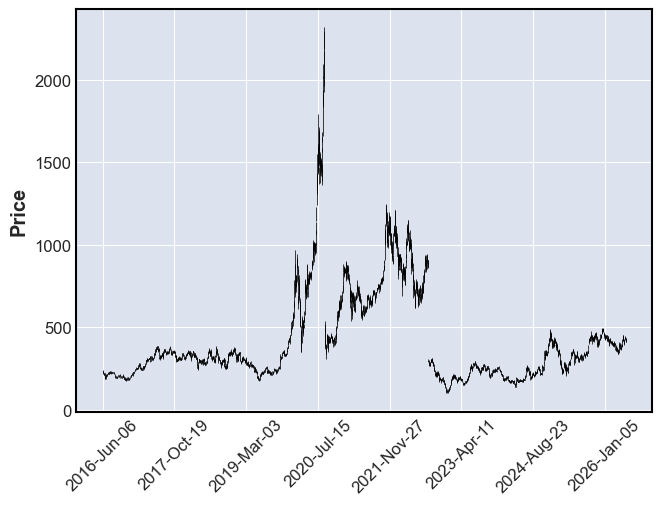

In [14]:
daily = bars.resample('1D').agg({'open': 'first', 
                                 'high': 'max', 
                                 'low': 'min', 
                                 'close': 'last'})
mpf.plot(daily, type='ohlc', show_nontrading=False, warn_too_much_data=1000000)

In [15]:
bars['date'] = bars.index.date
bars['close_original'] = bars['close']
bars = bars.merge(splits, left_on='date', right_index=True, how='left')
bars[['open', 'high', 'low', 'close']] = bars[['open', 'high', 'low', 'close']].\
    multiply(bars["cumulative_adjustment"], axis="index")

bars['turnover'] = bars['volume'] * bars['close_original']

In [16]:
bars

,open,high,low,close,volume,transactions,date,close_original,cumulative_adjustment,turnover
datetime,,,,,,,,,,
2016-06-06 08:00:00,14.604667,14.604667,14.604667,14.604667,431,7,2016-06-06,219.07,0.066667,94419.17
2016-06-06 08:02:00,14.634000,14.634000,14.634000,14.634000,250,3,2016-06-06,219.51,0.066667,54877.50
2016-06-06 08:08:00,14.633333,14.633333,14.633333,14.633333,517,2,2016-06-06,219.50,0.066667,113481.50
2016-06-06 08:16:00,14.606667,14.606667,14.606667,14.606667,181,3,2016-06-06,219.10,0.066667,39657.10
2016-06-06 08:28:00,14.606667,14.606667,14.606667,14.606667,402,3,2016-06-06,219.10,0.066667,88078.20
...,...,...,...,...,...,...,...,...,...,...
2026-06-03 19:55:00,420.176600,420.330000,420.170000,420.300000,1110,42,2026-06-03,420.30,1.000000,466533.00
2026-06-03 19:56:00,420.230000,420.260000,420.000000,420.000000,2364,71,2026-06-03,420.00,1.000000,992880.00
2026-06-03 19:57:00,419.930000,420.110000,419.820000,419.900000,1063,55,2026-06-03,419.90,1.000000,446353.70


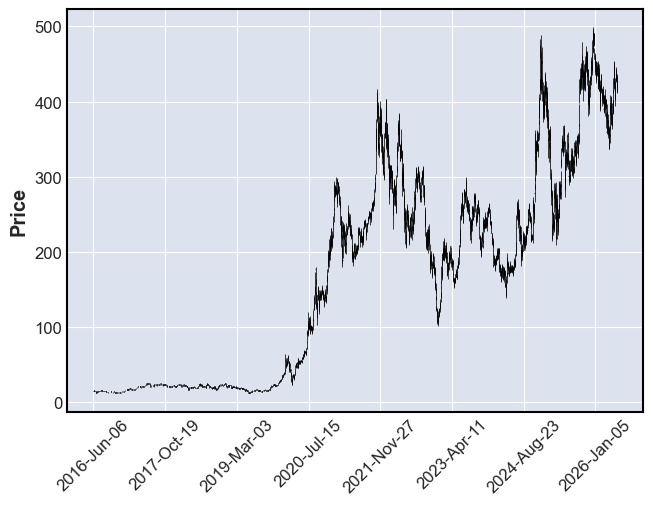

In [17]:
daily = bars.resample('1D').agg({'open': 'first', 
                                 'high': 'max', 
                                 'low': 'min', 
                                 'close': 'last'})
mpf.plot(daily, type='ohlc', show_nontrading=False, warn_too_much_data=1000000)

### Also, note that we need to apply ALL adjustments ("from" and "to") to apply to the "from" tickers!
2. Join ALL adjustments ("from" and "to") to apply to the "from" tickers!
- Concatenates `from_ticker` and `to_ticker` adjustment files. Catches splits/dividends that Polygon attached only to the new ticker.
- `splits = pd.concat([splits, splits_to])`

3. Apply ALL adjustments ("from" and "to") to the "from" tickers and ONLY "to" adjustments to the "to" tickers.
- Runs `split_adjust()` and `dividend_adjust()` **once** on each ticker’s raw bars. | This is the single source of truth – no later duplication.


Putting it all together in a function yields:

In [61]:
# helper function to get Splits data (including taking care of renamings)
def get_splits(ticker, trading_dates_ticker):
    # Get Splits data (including taking care of renamings)
    splits = pd.DataFrame()
    if os.path.isfile(DATA_PATH + f"raw/adjustments/{ticker}.csv"):
        adjustments = pd.read_csv(DATA_PATH + f"raw/adjustments/{ticker}.csv", parse_dates=True, index_col=0)
        adjustments.index = pd.to_datetime(adjustments.index).date

        # BUG_FIX = The next line is a bug! Why would we restrict adjustments that we need from ticker_to to the dates from the "from" ticker! Remove the next line! 
        # This cuts off any split that happens after the last trading day of the old ticker (usually the rename date).
        # But those later splits (e.g., a 2‑for‑1 split of the new ticker a month after the rename) must be applied backward to the old ticker’s history to make the price scale continuous.
        # Removing this filter allows all splits from the new ticker to be included, and the cumulative adjustment logic will correctly propagate them backward (via .bfill()).
        # adjustments = adjustments[(adjustments.index > trading_dates_ticker[0]) & (adjustments.index <= trading_dates_ticker[-1])]

        splits = adjustments[adjustments.type == "SPLIT"].copy()

    # ==========================================
    # ---- Merge splits from the FUTURE ticker if this ticker is a 'from' (old) ticker ----
    # The code below only merges splits from the to ticker when the current ticker is a ‘from’ (old) ticker. 
    # The "if" condition ensures it only affects ‘from’ tickers.

    # --- Apply ALL adjustments ("from" and "to") to the "from" tickers and ONLY "to" adjustments to the "to" tickers ---
    ticker_changes = pd.read_csv(DATA_PATH + "../stockanalysis/ticker_changes.csv")
    has_ticker_change = False
    if len(ticker_changes[ticker_changes['from'] == ticker]['to']) != 0:
        ticker_to = ticker_changes[ticker_changes['from'] == ticker]['to'].values[0]
        has_ticker_change = True

    if has_ticker_change and os.path.isfile(DATA_PATH + f"raw/adjustments/{ticker_to}.csv"):
        adjustments_to = pd.read_csv(DATA_PATH + f"raw/adjustments/{ticker_to}.csv", parse_dates=True, index_col=0)
        adjustments_to.index = pd.to_datetime(adjustments_to.index).date
        
        # BUG_FIX = The next line is a bug! Why would we restrict adjustments that we need from ticker_to to the dates from the "from" ticker! Remove the next line! 
        # adjustments_to = adjustments_to[(adjustments_to.index > trading_dates_ticker[0]) & (adjustments_to.index <= trading_dates_ticker[-1])]
        
        splits_to = adjustments_to[adjustments_to.type == "SPLIT"].copy()
        splits = pd.concat([splits, splits_to])
        splits = splits.drop_duplicates()
    # ==========================================

    if not splits.empty:
        splits['cumulative_adjustment'] = splits['amount'][::-1].cumprod()
        splits = splits.drop(columns=['type', 'subtype', 'amount'], errors='ignore')

        # --- DIAGNOSTIC LOGGING FOR SPLITS ---
        if splits.index.duplicated().any():
            print(f"⚠️ FOUND DUPLICATE SPLITS FOR TICKER: {ticker}")
            # Find the dates causing the crash
            duplicate_dates = splits.index[splits.index.duplicated()].unique()
            print(f"Duplicated mapped dates: {duplicate_dates.tolist()}")
            # Print the actual overlapping rows
            print(splits.loc[duplicate_dates], "\n")

        # --- FIX FOR DUPLICATE SPLITS ---
        # Keep the first row, because its cumulative product calculation already 
        # includes the combined math of all splits on that day
        splits = splits[~splits.index.duplicated(keep='first')]

        # Map split dates to previous trading day
        # Shift dates 1 day back 
        # In Live trading, when a stock split happens, the stock opens at an "already split" Price. That's what we have to replicate in backtests. 
        # So we have to make sure that the price BEFORE this day is split-adjusted by us - for a seamless time-series.
        # And the reason we cannot just use timedelta(days=1) is because that might not be a trading date.
        # This is a robust data-handling practice that ensures the adjustment aligns perfectly with actual market data, avoiding gaps or index errors caused by non-trading days.
        splits.index = splits.index.map(lambda day : max(d for d in trading_dates_ticker if d < day)) 
        
        # Now it is safe to reindex
        # reindex overwrites the structure (the index) but preserves the data through label alignment—provided your mapped labels exist in the target list.
        splits = splits.reindex(trading_dates_ticker)

        splits.cumulative_adjustment = splits.cumulative_adjustment.bfill().fillna(1) # Backward fill and fill ones

    return splits


In [94]:
def split_adjust(bars, ticker):
    """
    Returns the split-adjusted bars and add a column with the original close price.
    If there is no split-data, the original bars are returned.
    """
    bars['close_original'] = bars['close']
    bars['turnover'] = bars['volume'] * bars['close_original']

    trading_dates_ticker = sorted(list(set(bars.index.date)))

    # Get Splits data (including taking care of renamings)
    splits = get_splits(ticker, trading_dates_ticker)

    if not splits.empty:
        # Merge adjustments with the bars and adjust
        bars['date'] = bars.index.date
        bars = bars.merge(splits, left_on='date', right_index=True, how='left')
        bars['close_original'] = bars['close']
        bars[['open', 'high', 'low', 'close']] = bars[['open', 'high', 'low', 'close']].\
            multiply(bars["cumulative_adjustment"], axis="index")

        bars.drop(columns=['cumulative_adjustment', 'date'], inplace=True)

    return bars[['open', 'high', 'low', 'close', 'close_original', 'turnover', 'volume', 'transactions']]

In [95]:
""" # TO BE DELETED

def split_adjust(bars, ticker):
    # Returns the split-adjusted bars and add a column with the original close price.
    # If there is no split-data, the original bars are returned.
    bars['close_original'] = bars['close']
    bars['turnover'] = bars['volume'] * bars['close_original']

    trading_dates_ticker = sorted(list(set(bars.index.date)))

    # Get Splits data (including taking care of renamings)
    splits = get_splits(ticker, trading_dates_ticker)

    splits = pd.DataFrame()
    trading_dates_ticker = sorted(list(set(bars.index.date)))
    if os.path.isfile(DATA_PATH + f"raw/adjustments/{ticker}.csv"):
        adjustments = pd.read_csv(DATA_PATH + f"raw/adjustments/{ticker}.csv", parse_dates=True, index_col=0)
        adjustments.index = pd.to_datetime(adjustments.index).date
        adjustments = adjustments[(adjustments.index > trading_dates_ticker[0]) & (adjustments.index <= trading_dates_ticker[-1])]

        splits = adjustments[adjustments.type == "SPLIT"].copy()

    # ==========================================
    # ---- Merge splits from the FUTURE ticker if this ticker is a 'from' (old) ticker ----
    # The code below only merges splits from the to ticker when the current ticker is a ‘from’ (old) ticker. 
    # The "if" condition ensures it only affects ‘from’ tickers.

    # --- Apply ALL adjustments ("from" and "to") to the "from" tickers and ONLY "to" adjustments to the "to" tickers ---
    ticker_changes = pd.read_csv(DATA_PATH + "../stockanalysis/ticker_changes.csv")
    has_ticker_change = False
    if len(ticker_changes[ticker_changes['from'] == ticker]['to']) != 0:
        ticker_to = ticker_changes[ticker_changes['from'] == ticker]['to'].values[0]
        has_ticker_change = True

    if has_ticker_change and os.path.isfile(DATA_PATH + f"raw/adjustments/{ticker_to}.csv"):
        adjustments_to = pd.read_csv(DATA_PATH + f"raw/adjustments/{ticker_to}.csv", parse_dates=True, index_col=0)
        adjustments_to.index = pd.to_datetime(adjustments_to.index).date
        
        # BUG_FIX = The next line is a bug! Why would we restrict adjustments that we need from ticker_to to the dates from the "from" ticker! Remove the next line! 
        # This cuts off any split that happens after the last trading day of the old ticker (usually the rename date).
        # But those later splits (e.g., a 2‑for‑1 split of the new ticker a month after the rename) must be applied backward to the old ticker’s history to make the price scale continuous.
        # Removing this filter allows all splits from the new ticker to be included, and the cumulative adjustment logic will correctly propagate them backward (via .bfill()).
        # adjustments_to = adjustments_to[(adjustments_to.index > trading_dates_ticker[0]) & (adjustments_to.index <= trading_dates_ticker[-1])]
        
        splits_to = adjustments_to[adjustments_to.type == "SPLIT"].copy()
        splits = pd.concat([splits, splits_to])
        splits = splits.drop_duplicates()
    # ==========================================

    # Adjust for splits
    if not splits.empty:
        splits['cumulative_adjustment'] = splits['amount'][::-1].cumprod()
        splits = splits.drop(columns=['type', 'subtype', 'amount'])

        # Map split dates to previous trading day
        splits.index = splits.index.map(lambda day : max(d for d in trading_dates_ticker if d < day)) 
        
        # ==========================================
        # --- DIAGNOSTIC LOGGING FOR SPLITS ---
        if splits.index.duplicated().any():
            print(f"⚠️ FOUND DUPLICATE SPLITS FOR TICKER: {ticker}")
            # Find the dates causing the crash
            duplicate_dates = splits.index[splits.index.duplicated()].unique()
            print(f"Duplicated mapped dates: {duplicate_dates.tolist()}")
            # Print the actual overlapping rows
            print(splits.loc[duplicate_dates], "\n")
        # ==========================================

        # --- FIX FOR DUPLICATE SPLITS ---
        # Keep the first row, because its cumulative product calculation already 
        # includes the combined math of all splits on that day
        splits = splits[~splits.index.duplicated(keep='first')]
        # --------------------------------

        # Now it is safe to reindex
        splits = splits.reindex(trading_dates_ticker)

        splits.cumulative_adjustment = splits.cumulative_adjustment.bfill().fillna(1) # Backward fill and fill ones

    if not splits.empty:
        # Merge adjustments with the bars and adjust
        bars['date'] = bars.index.date
        bars = bars.merge(splits, left_on='date', right_index=True, how='left')
        bars['close_original'] = bars['close']
        bars[['open', 'high', 'low', 'close']] = bars[['open', 'high', 'low', 'close']].\
            multiply(bars["cumulative_adjustment"], axis="index")

        bars.drop(columns=['cumulative_adjustment', 'date'], inplace=True)

    return bars[['open', 'high', 'low', 'close', 'close_original', 'turnover', 'volume', 'transactions']] """

' # TO BE DELETED\n\ndef split_adjust(bars, ticker):\n    # Returns the split-adjusted bars and add a column with the original close price.\n    # If there is no split-data, the original bars are returned.\n    bars[\'close_original\'] = bars[\'close\']\n    bars[\'turnover\'] = bars[\'volume\'] * bars[\'close_original\']\n\n    trading_dates_ticker = sorted(list(set(bars.index.date)))\n\n    # Get Splits data (including taking care of renamings)\n    splits = get_splits(ticker, trading_dates_ticker)\n\n    splits = pd.DataFrame()\n    trading_dates_ticker = sorted(list(set(bars.index.date)))\n    if os.path.isfile(DATA_PATH + f"raw/adjustments/{ticker}.csv"):\n        adjustments = pd.read_csv(DATA_PATH + f"raw/adjustments/{ticker}.csv", parse_dates=True, index_col=0)\n        adjustments.index = pd.to_datetime(adjustments.index).date\n        adjustments = adjustments[(adjustments.index > trading_dates_ticker[0]) & (adjustments.index <= trading_dates_ticker[-1])]\n\n        splits = 

## Adjust Volume for Splits (already adjusted by Polygon)
Verified in "05_download_adjustments.ipynb"

## Adjust Cash Dividends for Splits (Forward, Reverse and Stock Dividends), (NOT split adjusted by Polygon. MUST be done)

### Cash Dividends are NOT adjusted for splits by Polygon! MUST be done by us. Verified in 05_download_adjustments.ipynb
### It's crucial to adjust Dividends for Splits!
https://massive.com/knowledge-base/article/does-massive-adjust-historic-dividends-for-splits


Why this is crucial:

https://aistudio.google.com/app/prompts?state=%7B%22ids%22:%5B%221CmuSHfJT0xy4UGGdELP5RLbrclRjvgiR%22%5D,%22action%22:%22open%22,%22userId%22:%22104962803681652166866%22,%22resourceKeys%22:%7B%7D%7D&usp=sharing

Imagine a stock in 2015. 
*   **Actual 2015 Price:** $100
*   **Actual 2015 Dividend Paid:** $4 per share
*   **Actual Dividend Yield in 2015:** 4% ($4 / $100)

Now, in 2020, the company does a **4-for-1 stock split**. 
Fast forward to today. You are pulling historical data for a backtest. Because of the 4-for-1 split, your data provider adjusts the historical 2015 price down by a factor of 4 to stitch the time series together smoothly.
*   **Adjusted 2015 Price:** $25 ($100 / 4)

**Here is where the problem happens if you DON'T adjust the dividend:**
If you take the *Adjusted 2015 Price* ($25) but use the *Unadjusted 2015 Dividend* ($4), your backtesting engine will calculate the historical dividend yield as:
$4 / $25 = **16% Dividend Yield.**

Suddenly, your backtest thinks this stock was yielding 16% in 2015. Your algorithmic value-factor strategy goes crazy, buys a massive simulated position, and shows you incredible backtested returns. In reality, the yield was only 4%. You've just introduced a massive data artifact.

To fix this, the data provider **adjusts the historical dividend for the split** (dividing it by 4).
*   **Adjusted 2015 Dividend:** $1 ($4 / 4)
*   **Correct Yield Calculation:** $1 / $25 = **4%**. 

Math is preserved. Reality is preserved.

### Adjust Cash Dividends for Splits (Forward, Reverse and Stock Dividends)

We must adjust historic cash dividends to account for stock splits. 
Because cash dividend events are tied to the **ex-dividend date**, a dividend only needs to be adjusted by splits that executed **after** the dividend's ex-date. If a dividend goes ex on the exact same day a split executes, it is already trading on a post-split basis and should not be adjusted by that specific split.

Strict `>` not `>=` on the date comparison. If a split and a dividend share the same date, the dividend is typically declared on a pre-split basis (the record date precedes the execution date), so the split should not be applied. Using `>` is the conservative and correct side to err on.


In [96]:
split_adjusted_bars = split_adjust(pd.read_parquet(DATA_PATH + f"raw/m1/BIL.parquet"), 'BIL')
trading_dates_ticker = sorted(list(set(bars.index.date)))

adjustments = pd.read_csv(DATA_PATH + f"raw/adjustments/BIL.csv", parse_dates=True, index_col=0)
adjustments.index = pd.to_datetime(adjustments.index).date
# BUG_FIX = The next line is a bug! Why would we restrict adjustments that we need from ticker_to to the dates from the "from" ticker! Remove the next line! 
# adjustments = adjustments[(adjustments.index > trading_dates_ticker[0]) & (adjustments.index <= trading_dates_ticker[-1])]

dividends = adjustments[adjustments.type == "DIV"].copy()
dividends

,type,subtype,amount
2016-12-01,DIV,CD,0.021036
2016-12-28,DIV,CD,0.009357
2017-02-01,DIV,CD,0.012558
2017-03-01,DIV,CD,0.012181
2017-04-03,DIV,CD,0.014439
...,...,...,...
2026-02-02,DIV,CD,0.273931
2026-03-02,DIV,CD,0.243106
2026-04-01,DIV,CD,0.263657
2026-05-01,DIV,CD,0.269910


In [97]:
# 2. Extract raw splits again to calculate pure split factors 
# (This avoids the date-shifting complexities applied during the Price adjustment step)
raw_splits = adjustments[adjustments.type == "SPLIT"].copy()
# Calculate the cumulative product from the most recent split backwards
raw_splits['cumulative_adjustment'] = raw_splits['amount'][::-1].cumprod()
raw_splits

,type,subtype,amount,cumulative_adjustment
2017-11-30,SPLIT,R,2.0,2.0


In [98]:
def get_split_factor_for_dividend(div_date):
    """
    Finds the cumulative split adjustment for a given dividend date.
    A dividend going ex on date D must be adjusted by all splits 
    that have an execution date strictly greater than D.
    """
    future_splits = raw_splits[raw_splits.index > div_date]
    if future_splits.empty:
        return 1.0
    else:
        # The earliest future split contains the cumulative product of all future splits
        return future_splits.iloc[0]['cumulative_adjustment']

In [99]:
dividends = dividends.rename(columns={'amount': 'dividend_amount'})

# 3. Map the split factor based on the ex-dividend date
# dividends['cumulative_adjustment'] = dividends.index.map(get_split_factor_for_dividend)
dividends['cumulative_adjustment'] = [get_split_factor_for_dividend(d) for d in dividends.index]

# 4. Calculate the final split-adjusted dividend amount
dividends['adjusted_dividend_amount'] = dividends['dividend_amount'] * dividends['cumulative_adjustment']

# Drop unneeded columns for a cleaner DataFrame
dividends = dividends.drop(columns=['type', 'subtype'], errors='ignore')

In [100]:
dividends

,dividend_amount,cumulative_adjustment,adjusted_dividend_amount
2016-12-01,0.021036,2.0,0.042072
2016-12-28,0.009357,2.0,0.018714
2017-02-01,0.012558,2.0,0.025116
2017-03-01,0.012181,2.0,0.024362
2017-04-03,0.014439,2.0,0.028878
...,...,...,...
2026-02-02,0.273931,1.0,0.273931
2026-03-02,0.243106,1.0,0.243106
2026-04-01,0.263657,1.0,0.263657
2026-05-01,0.269910,1.0,0.269910


# 7.3 "Split-Adjusted" Cash Dividend adjustment applied to Price
We use the [stockcharts](https://support.stockcharts.com/doku.php?id=policies:historical_price_data_is_adjusted_for_splits_dividends_and_distributions#:~:text=Dividend%20Adjustment%20Calculation%20Details%3A,then%20multiplied%20by%20this%20factor) or [Yahoo](https://help.yahoo.com/kb/SLN28256.html) method to adjust dividends, which mimics dividend reinvesting at the close of cum-dividend date. If at cum-dividend the price is 60, and at ex-dividend is 50 after a 10/share dividend, then all prices from cum-dividend and before are adjusted by the factor *1 - (dividend/cumdividend close)*. So the adjusted cum-dividend close will be 50. 

Note: Even though the close (which can differ on early close days) is used to calculate the adjustment factor, the post-market prices also have to be adjusted. 

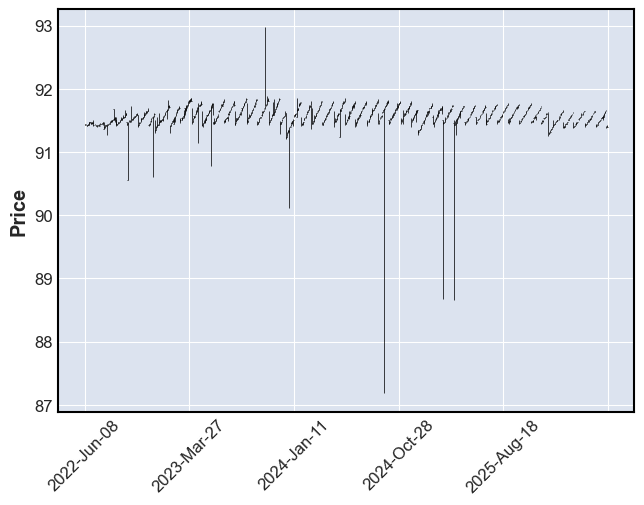

In [101]:
daily = split_adjusted_bars.resample('1D').agg({'open': 'first', 
                                 'high': 'max', 
                                 'low': 'min', 
                                 'close': 'last'})
daily.dropna(inplace=True)
mpf.plot(daily.tail(1000), type='ohlc', show_nontrading=False, warn_too_much_data=1000000)

Let's first get the cum_div_dates.

In [102]:
dividends['cum_div_date'] = dividends.index.map(\
    lambda day : max(d for d in trading_dates_ticker if d < day))
dividends = dividends[['dividend_amount', 'cum_div_date']]
dividends.index.names = ['ex_div_date']
dividends.head(3)

,dividend_amount,cum_div_date
ex_div_date,,
2016-12-01,0.021036,2016-11-30
2016-12-28,0.009357,2016-12-27
2017-02-01,0.012558,2017-01-31


In [103]:
# We need to get the ex-dividend closing price. Most days this is on 16:00 ET. Some days have early closes.
market_hours = get_market_calendar('datetime')
market_hours = market_hours[['regular_close']]

In [104]:
dividends.set_index(dividends['cum_div_date'], inplace=True)
dividends['cum_div_datetime'] = market_hours.loc[dividends.index, 'regular_close']

# Sometimes the latest trade of the day is NOT the 15:59 bar exactly. 
# So we need to get the latest available price at or before the close.
dividends['cum_div_datetime'] = dividends['cum_div_datetime'].apply(\
    lambda dt : (split_adjusted_bars[split_adjusted_bars.index <= dt].index).max())
dividends.set_index(dividends['cum_div_datetime'], inplace=True)
dividends['cum_div_close'] = split_adjusted_bars.loc[dividends['cum_div_datetime'], 'close']

In [105]:
dividends

,dividend_amount,cum_div_date,cum_div_datetime,cum_div_close
cum_div_datetime,,,,
2016-11-30 15:59:00,0.021036,2016-11-30,2016-11-30 15:59:00,91.4600
2016-12-27 15:59:00,0.009357,2016-12-27,2016-12-27 15:59:00,91.4400
2017-01-31 15:59:00,0.012558,2017-01-31,2017-01-31 15:59:00,91.4500
2017-02-28 15:59:00,0.012181,2017-02-28,2017-02-28 15:59:00,91.4600
2017-03-31 15:59:00,0.014439,2017-03-31,2017-03-31 15:59:00,91.4400
...,...,...,...,...
2026-01-30 15:59:00,0.273931,2026-01-30,2026-01-30 15:59:00,91.6500
2026-02-27 15:59:00,0.243106,2026-02-27,2026-02-27 15:59:00,91.6201
2026-03-31 15:59:00,0.263657,2026-03-31,2026-03-31 15:59:00,91.6500


In [106]:
dividends['adjustment'] = 1 - (dividends['dividend_amount'] / dividends['cum_div_close'])
dividends['cumulative_adjustment'] = dividends['adjustment'][::-1].cumprod()

In [107]:
dividends

,dividend_amount,cum_div_date,cum_div_datetime,cum_div_close,adjustment,cumulative_adjustment
cum_div_datetime,,,,,,
2016-11-30 15:59:00,0.021036,2016-11-30,2016-11-30 15:59:00,91.4600,0.999770,0.808314
2016-12-27 15:59:00,0.009357,2016-12-27,2016-12-27 15:59:00,91.4400,0.999898,0.808500
2017-01-31 15:59:00,0.012558,2017-01-31,2017-01-31 15:59:00,91.4500,0.999863,0.808583
2017-02-28 15:59:00,0.012181,2017-02-28,2017-02-28 15:59:00,91.4600,0.999867,0.808694
2017-03-31 15:59:00,0.014439,2017-03-31,2017-03-31 15:59:00,91.4400,0.999842,0.808801
...,...,...,...,...,...,...
2026-01-30 15:59:00,0.273931,2026-01-30,2026-01-30 15:59:00,91.6500,0.997011,0.985681
2026-02-27 15:59:00,0.243106,2026-02-27,2026-02-27 15:59:00,91.6201,0.997347,0.988636
2026-03-31 15:59:00,0.263657,2026-03-31,2026-03-31 15:59:00,91.6500,0.997123,0.991266


In [108]:
dividends.set_index(dividends['cum_div_date'], inplace=True, drop=True)
dividend_adjustments = dividends[['cumulative_adjustment']]

# Get dividend adjustments for every trading day (same procedure as split adjustments)
dividend_adjustments = dividend_adjustments.reindex(trading_dates_ticker) # Reindex using stock data 
dividend_adjustments['cumulative_adjustment'] = dividend_adjustments['cumulative_adjustment'].bfill().fillna(1) # Backward fill and fill ones

In [109]:
dividend_adjustments

,cumulative_adjustment
cum_div_date,
2016-06-06,0.808314
2016-06-07,0.808314
2016-06-08,0.808314
2016-06-09,0.808314
2016-06-10,0.808314
...,...
2026-05-28,0.997063
2026-05-29,0.997063
2026-06-01,1.000000


In [110]:
# Same procedure as with split adjustments
all_adjusted_bars = split_adjusted_bars.copy()
all_adjusted_bars['date'] = all_adjusted_bars.index.date
all_adjusted_bars = all_adjusted_bars.merge(dividend_adjustments, left_on='date', right_index=True, how='left')
all_adjusted_bars[['open', 'high', 'low', 'close']] = all_adjusted_bars[['open', 'high', 'low', 'close']].\
    multiply(all_adjusted_bars["cumulative_adjustment"], axis="index")
all_adjusted_bars.drop(columns=['cumulative_adjustment', 'date'], inplace=True)

# Round to 4 decimals
all_adjusted_bars = round(all_adjusted_bars, 4)

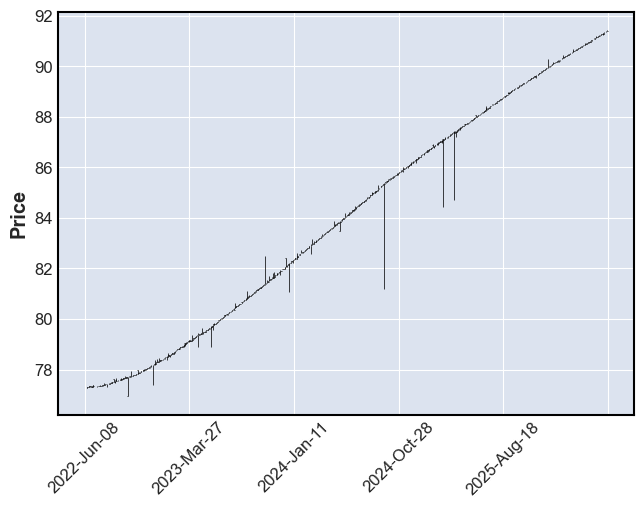

In [111]:
daily = all_adjusted_bars.resample('1D').agg({'open': 'first', 
                                 'high': 'max', 
                                 'low': 'min', 
                                 'close': 'last'})
daily.dropna(inplace=True)
mpf.plot(daily.tail(1000), type='ohlc', show_nontrading=False, warn_too_much_data=1000000)

### First we "Split-adjust" the Dividends!

In [112]:
def get_dividends(ticker, trading_dates_ticker):
    # Loads raw adjustments for a ticker, extracts cash dividends, 
    # and applies forward/reverse split factors to historical dividends so they accurately match the current share count.
    try:
        # Load the raw adjustments file containing both SPLIT and DIV
        adjustments = pd.read_csv(DATA_PATH + f"raw/adjustments/{ticker}.csv", parse_dates=True, index_col=0)
        # Guard against empty files or missing columns
        if adjustments.empty or 'type' not in adjustments.columns:
            return pd.DataFrame()
        adjustments.index = pd.to_datetime(adjustments.index).date
    except FileNotFoundError:
        return pd.DataFrame()

    # 1. Extract cash dividends
    dividends = adjustments[adjustments['type'] == "DIV"].copy()
    if dividends.empty:
        return pd.DataFrame()

    dividends = dividends.rename(columns={'amount': 'dividend_amount'})
        
    # 2. Get Splits data (including taking care of renamings)
    raw_splits = get_splits(ticker, trading_dates_ticker)

    # If there are no splits, just return the untouched dividends
    if raw_splits.empty:
        dividends['cumulative_adjustment'] = 1.0
        dividends['adjusted_dividend_amount'] = dividends['dividend_amount']
        return dividends.drop(columns=['type', 'subtype'], errors='ignore')
        
    # Calculate the cumulative product from the most recent split backwards
    # raw_splits['cumulative_adjustment'] = raw_splits['amount'][::-1].cumprod()

    # Helper to find cumulative split adjustment for a given dividend date
    def get_split_factor_for_dividend(div_date):
        future_splits = raw_splits[raw_splits.index > div_date]
        if future_splits.empty:
            return 1.0
        else:
            return future_splits.iloc[0]['cumulative_adjustment']

    # 3. Map the split factor based on the ex-dividend date
    dividends['cumulative_adjustment'] = [get_split_factor_for_dividend(d) for d in dividends.index]

    # 4. Calculate the final split-adjusted dividend amount
    dividends['adjusted_dividend_amount'] = dividends['dividend_amount'] * dividends['cumulative_adjustment']

    # Clean up and return
    return dividends.drop(columns=['type', 'subtype'], errors='ignore')

### Next we create a function to apply the "split-adjusted" Dividends to the OHLC data to make it Dividend-adjusted.

Putting it all in a function yields:

In [146]:
def div_adjust(split_adjusted_bars, ticker):
    """
    Dividend-adjust the 1-minute bars using split-adjusted dividend amounts.
    
    Returns a tuple: (adjusted_bars_df, break_meta_dict)
    
    break_meta keys:
        has_break       bool   – True if a structural break dividend was detected
        blacklist_date  date   – first untradeable day (ex_date); None if no break
        last_valid_date date   – last tradeable day (cum_div_date); None if no break
        trigger_ratio   float  – amount / prior_close that caused the break
        trigger_amount  float  – raw dividend amount
        prior_close     float  – closing price on cum_div_date
    """
    all_adjusted_bars = split_adjusted_bars.copy()

    # ── NEW: initialise break_meta unconditionally so the return is always a clean tuple ──
    break_meta = {
        'has_break':       False,
        'blacklist_date':  None,
        'last_valid_date': None,
        'trigger_ratio':   None,
        'trigger_amount':  None,
        'prior_close':     None,
    }
    # ─────────────────────────────────────────────────────────────────────────────────────

    if os.path.isfile(DATA_PATH + f"raw/adjustments/{ticker}.csv"):
        trading_dates_ticker = sorted(list(set(split_adjusted_bars.index.date)))

        # 1. Load the correctly split-adjusted dividends using the helper function
        dividends = get_dividends(ticker, trading_dates_ticker)
        
        # Filter out dividends that occurred before the first available trading day
        # Needed to make the `dividends.index.map` code work below.
        # And since those dividends happened before your data starts, they don't affect any prices in the series. You can safely filter them out before mapping.
        dividends = dividends[dividends.index >= trading_dates_ticker[0]] # keep only dates >= first trading day

        if not dividends.empty:
            # BUG_FIX = The next line is a bug! Why would we restrict adjustments that we need from ticker_to to the dates from the "from" ticker! Remove the next line! 
            # dividends = dividends[(dividends.index > trading_dates_ticker[0]) & (dividends.index <= trading_dates_ticker[-1])].copy()
            
            # Get cum div date
            dividends['cum_div_date'] = dividends.index.map(lambda day : max(d for d in trading_dates_ticker if d < day))

            # 3. Keep the split-adjusted amount, and rename it to 'amount' so the rest of your closing-price logic functions exactly as before
            dividends = dividends[['adjusted_dividend_amount', 'cum_div_date']]
            dividends = dividends.rename(columns={'adjusted_dividend_amount': 'amount'})
            
            # ==========================================
            # --- DIAGNOSTIC LOGGING FOR DIVIDENDS ---
            if dividends.duplicated(subset=['cum_div_date']).any():
                print(f"⚠️ COMBINING MULTIPLE DIVIDENDS FOR TICKER: {ticker}")
                duplicate_dates = dividends[dividends.duplicated(subset=['cum_div_date'])]['cum_div_date'].unique()
                print(f"Duplicated cum_div_dates: {duplicate_dates.tolist()}")
                print(dividends[dividends['cum_div_date'].isin(duplicate_dates)], "\n")
            # ==========================================

            # --- FIX FOR DUPLICATE DIVIDENDS ---
            dividends = dividends.groupby('cum_div_date', as_index=False).sum()
            # -----------------------------------
            
            dividends.index.names = ['ex_div_date']

            # We need to get the ex-dividend closing price.
            market_hours = get_market_calendar('datetime')
            market_hours = market_hours[['regular_close']]

            dividends.set_index(dividends['cum_div_date'], inplace=True)
            dividends['cum_div_datetime'] = market_hours.loc[dividends.index, 'regular_close']

            dividends['cum_div_datetime'] = dividends['cum_div_datetime'].apply(lambda dt : (split_adjusted_bars[split_adjusted_bars.index <= dt].index).max())
            dividends.set_index(dividends['cum_div_datetime'], inplace=True)
            dividends['cum_div_close'] = split_adjusted_bars.loc[dividends['cum_div_datetime'], 'close']

            # ── NEW: STRUCTURAL BREAK DETECTION ──────────────────────────────────────────
            # A structural break is any dividend that consumes >= STRUCTURAL_BREAK_THRESHOLD
            # of the prior close. The standard multiplicative formula produces a negative (or
            # near-zero) adjustment factor, which would corrupt all earlier bar prices.
            # We detect these here — after cum_div_close is known — rather than retroactively.
            dividends['break_ratio'] = dividends['amount'] / dividends['cum_div_close']
            structural_breaks = dividends[dividends['break_ratio'] >= STRUCTURAL_BREAK_THRESHOLD].copy()

            if not structural_breaks.empty:
                # Take the earliest break as the truncation point.
                # (Multiple breaks are extremely rare but handled correctly this way.)
                structural_breaks = structural_breaks.sort_values('cum_div_date')
                earliest = structural_breaks.iloc[0]
                last_valid_date = earliest['cum_div_date']

                # blacklist_date = next trading day after last_valid_date (i.e. the actual
                # ex_date). This is the first day the stock is UNTRADEABLE.
                future_dates = [d for d in trading_dates_ticker if d > last_valid_date]
                blacklist_date = future_dates[0] if future_dates else last_valid_date

                break_meta.update({
                    'has_break':       True,
                    'blacklist_date':  blacklist_date,
                    'last_valid_date': last_valid_date,
                    'trigger_ratio':   round(float(earliest['break_ratio']), 4),
                    'trigger_amount':  round(float(earliest['amount']), 4),
                    'prior_close':     round(float(earliest['cum_div_close']), 4),
                })

                print(
                    f"🚫 STRUCTURAL BREAK | {ticker} | "
                    f"div={earliest['amount']:.4f}  close={earliest['cum_div_close']:.4f}  "
                    f"ratio={earliest['break_ratio']:.2f}x | "
                    f"last valid: {last_valid_date}  →  blacklisted from: {blacklist_date}"
                )

                # Truncate bars: keep only bars up to and including the last valid trading day.
                # This is the live-accurate view — on blacklist_date the stock is untradeable.
                all_adjusted_bars = all_adjusted_bars[
                    all_adjusted_bars.index.date <= last_valid_date
                ]

                # Remove structural break dividends from the adjustment chain.
                # Also drop any normal dividends whose cum_div_date falls in the
                # truncated-away range — their backward adjustment would otherwise
                # incorrectly flow into the pre-break prices via bfill.
                dividends = dividends[
                    (dividends['break_ratio'] < STRUCTURAL_BREAK_THRESHOLD) &
                    (dividends['cum_div_date'] <= last_valid_date)
                ].copy()

            # Always drop the helper column before continuing
            dividends = dividends.drop(columns=['break_ratio'], errors='ignore')
            # ─────────────────────────────────────────────────────────────────────────────

            # Calculate adjustments using the perfectly split-adjusted dividend 'amount'.
            # If dividends is now empty (all were structural breaks), these produce empty
            # Series and the reindex below fills everything with 1.0 — i.e. no adjustment,
            # which is exactly correct.
            dividends['adjustment'] = 1 - (dividends['amount'] / dividends['cum_div_close'])
            dividends['cumulative_adjustment'] = dividends['adjustment'][::-1].cumprod()

            dividends.set_index(dividends['cum_div_date'], inplace=True, drop=True)
            dividend_adjustments = dividends[['cumulative_adjustment']]

            dividend_adjustments = dividend_adjustments.reindex(trading_dates_ticker)
            dividend_adjustments['cumulative_adjustment'] = dividend_adjustments['cumulative_adjustment'].bfill().fillna(1)

            # Same procedure as with split adjustments
            all_adjusted_bars['date'] = all_adjusted_bars.index.date
            all_adjusted_bars = all_adjusted_bars.merge(dividend_adjustments, left_on='date', right_index=True, how='left')
            all_adjusted_bars[['open', 'high', 'low', 'close']] = all_adjusted_bars[['open', 'high', 'low', 'close']].\
                multiply(all_adjusted_bars["cumulative_adjustment"], axis="index")

            all_adjusted_bars.drop(columns=['cumulative_adjustment', 'date'], inplace=True)

    # Round to 4 decimals
    # ── MODIFIED: now returns a tuple so cell 48 can act on break_meta ──
    return round(all_adjusted_bars, 4), break_meta

# 7.4 Reindexing and NA values

When reindexing we need to get a list of all minutes. Since we will also have to do this in the backtester (which loops over the minutes), we will store it and create a function to retrieve it.

In [147]:
###
market_hours = get_market_calendar()

# Get all minutes from trading days
trading_datetimes = pd.date_range(start=market_hours.index[0], \
                                  end=datetime.combine(market_hours.index[-1], time(23, 59)), freq='min', name='datetime')
trading_datetimes[(trading_datetimes.time >= time(4, 0)) & (trading_datetimes.time <= time(19, 59))]

# Filter to all trading minutes in trading days
trading_datetimes = trading_datetimes[trading_datetimes.to_series().dt.date.isin(market_hours.index)]
trading_datetimes = trading_datetimes[(trading_datetimes.time >= time(4)) & (trading_datetimes.time <= time(19, 59))] 

# Remove the minutes in early closes (from 17:00 to 19:59 there is no post-market on early close days)
early_closes = market_hours[market_hours['postmarket_close'] != time(19, 59)]
for day, early_close in early_closes.iterrows():
    postmarket_close = early_close['postmarket_close']
    trading_datetimes = trading_datetimes[~((trading_datetimes > datetime.combine(day, early_close['postmarket_close'])) \
                                            & (trading_datetimes <= datetime.combine(day, time(19, 59)) ) )] 

pd.DataFrame(index=trading_datetimes).to_parquet(DATA_PATH + 'market/trading_minutes.parquet')

In [148]:
trading_datetimes_test = pd.read_parquet(DATA_PATH + 'market/trading_minutes.parquet')
trading_datetimes_test.head()

""
datetime
2016-06-06 04:00:00
2016-06-06 04:01:00
2016-06-06 04:02:00
2016-06-06 04:03:00
2016-06-06 04:04:00


In [149]:
test = pd.to_datetime(trading_datetimes_test.index)
test

DatetimeIndex(['2016-06-06 04:00:00', '2016-06-06 04:01:00',
               '2016-06-06 04:02:00', '2016-06-06 04:03:00',
               '2016-06-06 04:04:00', '2016-06-06 04:05:00',
               '2016-06-06 04:06:00', '2016-06-06 04:07:00',
               '2016-06-06 04:08:00', '2016-06-06 04:09:00',
               ...
               '2026-06-03 19:50:00', '2026-06-03 19:51:00',
               '2026-06-03 19:52:00', '2026-06-03 19:53:00',
               '2026-06-03 19:54:00', '2026-06-03 19:55:00',
               '2026-06-03 19:56:00', '2026-06-03 19:57:00',
               '2026-06-03 19:58:00', '2026-06-03 19:59:00'],
              dtype='datetime64[us]', name='datetime', length=2408700, freq=None)

In [150]:
from functools import lru_cache

# This decorator ensures that when we call a function the output is stored for future calls.
# This is useful if executing the function is expensive and gets called a lot.
@lru_cache
def get_market_minutes():
    trading_datetimes = pd.read_parquet(DATA_PATH + 'market/trading_minutes.parquet')
    return pd.to_datetime(trading_datetimes.index)

In [151]:
def reindex_and_fill(bars):
    # Get the days the ticker is trading
    ticker_days = sorted(list(set(bars.index.date)))
    market_datetimes = get_market_minutes()
    ticker_datetimes = market_datetimes[(market_datetimes.date >= ticker_days[0]) & (market_datetimes.date <= ticker_days[-1])]

    # Reindex
    bars = bars.reindex(ticker_datetimes)

    # Fill NA values
    bars['tradeable'] = ~bars['turnover'].isna()
    bars['turnover'] = bars['turnover'].fillna(0)
    bars['volume'] = bars['volume'].fillna(0)
    bars['transactions'] = bars['transactions'].fillna(0)

    bars["close"] = bars["close"].ffill()
    bars["close_original"] = bars["close_original"].ffill()
    bars["open"] = bars["open"].fillna(bars["close"])
    bars["low"] = bars["low"].fillna(bars["close"])
    bars["high"] = bars["high"].fillna(bars["close"])

    # Only affects the very start. Else backfill shouldn't be used because of look-ahead bias.
    # After ffill, any NaN that appears after at least one valid value has been filled. The only NaNs that survive ffill are those that occur before the first valid data point in the entire series — i.e., at the very beginning.
    # Then bfill is applied to the entire "open" column. Because the only remaining NaNs are at the start, backfilling affects only those leading missing values and does nothing to the rest of the series (where no NaNs exist anymore).
    bars["open"] = bars["open"].bfill()
    
    bars["close"] = bars["close"].fillna(bars["open"])
    bars["close_original"] = bars["close_original"].bfill() # Technically we should get the open_original, but I am not going to bother with the untradeable bars at the start that will never be used.
    bars["low"] = bars["low"].fillna(bars["open"])
    bars["high"] = bars["high"].fillna(bars["open"])
    
    return bars

In [152]:
bars = pd.read_parquet(f"{DATA_PATH}raw/m1/BIL.parquet")
bars

,open,high,low,close,volume,transactions
datetime,,,,,,
2016-06-06 09:30:00,45.7100,45.7100,45.7100,45.7100,1987,2
2016-06-06 09:32:00,45.7165,45.7165,45.7165,45.7165,215,1
2016-06-06 09:39:00,45.7100,45.7100,45.7100,45.7100,100,1
2016-06-06 09:43:00,45.7100,45.7100,45.7100,45.7100,200,1
2016-06-06 09:46:00,45.7101,45.7101,45.7100,45.7100,266,4
...,...,...,...,...,...,...
2026-06-03 19:53:00,91.4026,91.4026,91.4026,91.4026,630,4
2026-06-03 19:55:00,91.4100,91.4100,91.4099,91.4100,1110,6
2026-06-03 19:56:00,91.4001,91.4001,91.4001,91.4001,218,1


In [153]:
bars = pd.read_parquet(f"{DATA_PATH}raw/m1/BIL.parquet")
split_adjusted_bars = split_adjust(bars, "BIL")
all_adjusted_bars, break_meta = div_adjust(split_adjusted_bars, "BIL")   # unpack tuple
cleaned_data_test = reindex_and_fill(all_adjusted_bars)

In [154]:
cleaned_data_test.head()

,open,high,low,close,close_original,turnover,volume,transactions,tradeable
datetime,,,,,,,,,
2016-06-06 04:00:00,73.6786,73.6786,73.6786,73.6786,45.71,0.0,0.0,0.0,False
2016-06-06 04:01:00,73.6786,73.6786,73.6786,73.6786,45.71,0.0,0.0,0.0,False
2016-06-06 04:02:00,73.6786,73.6786,73.6786,73.6786,45.71,0.0,0.0,0.0,False
2016-06-06 04:03:00,73.6786,73.6786,73.6786,73.6786,45.71,0.0,0.0,0.0,False
2016-06-06 04:04:00,73.6786,73.6786,73.6786,73.6786,45.71,0.0,0.0,0.0,False


In [155]:
cleaned_data_test.tail()

,open,high,low,close,close_original,turnover,volume,transactions,tradeable
datetime,,,,,,,,,
2026-06-03 19:55:00,91.4100,91.4100,91.4099,91.4100,91.4100,101465.1000,1110.0,6.0,True
2026-06-03 19:56:00,91.4001,91.4001,91.4001,91.4001,91.4001,19925.2218,218.0,1.0,True
2026-06-03 19:57:00,91.4001,91.4001,91.4001,91.4001,91.4001,0.0000,0.0,0.0,False
2026-06-03 19:58:00,91.4100,91.4100,91.4100,91.4100,91.4100,361617.9600,3956.0,13.0,True
2026-06-03 19:59:00,91.4100,91.4100,91.4000,91.4000,91.4000,77415.8000,847.0,10.0,True


# ETF Dividends matter (VERIFY that they get download during "05_download_adjustments.ipynb" and applied in 07_process.ipynb)
When querying historical data for these via Yahoo Finance (yfinance), Polygon, or Alpaca, make sure you pull Adjusted Close (Adj Close). ETFs like HYG (Junk Bonds) and TLT (Treasuries) pay hefty monthly dividends. If your code uses raw Close prices instead of Adjusted Close prices, your moving averages will trigger fake breakdown signals every time the ETF goes ex-dividend.

In [156]:
bars = pd.read_parquet(f"{DATA_PATH}raw/m1/TLT.parquet")
bars.head()

,open,high,low,close,volume,transactions
datetime,,,,,,
2016-06-06 08:00:00,132.98,132.98,132.98,132.98,100,1
2016-06-06 08:09:00,132.83,132.83,132.75,132.75,1428,12
2016-06-06 08:13:00,132.78,132.78,132.78,132.78,148,2
2016-06-06 08:20:00,132.85,132.85,132.85,132.85,100,1
2016-06-06 08:45:00,132.75,132.75,132.73,132.73,1500,3


In [157]:
split_adjusted_bars = split_adjust(bars, "TLT")

In [158]:
all_adjusted_bars, break_meta = div_adjust(split_adjusted_bars, "TLT")   # ← unpack tuple
all_adjusted_bars

,open,high,low,close,close_original,turnover,volume,transactions
datetime,,,,,,,,
2016-06-06 08:00:00,100.6222,100.6222,100.6222,100.6222,132.9800,13298.00,100,1
2016-06-06 08:09:00,100.5087,100.5087,100.4482,100.4482,132.7500,189567.00,1428,12
2016-06-06 08:13:00,100.4709,100.4709,100.4709,100.4709,132.7800,19651.44,148,2
2016-06-06 08:20:00,100.5238,100.5238,100.5238,100.5238,132.8500,13285.00,100,1
2016-06-06 08:45:00,100.4482,100.4482,100.4330,100.4330,132.7300,199095.00,1500,3
...,...,...,...,...,...,...,...,...
2026-06-03 19:49:00,85.3200,85.3200,85.3200,85.3200,85.3200,23463.00,275,4
2026-06-03 19:55:00,85.3200,85.3201,85.3200,85.3201,85.3201,34128.04,400,2
2026-06-03 19:56:00,85.3500,85.3500,85.3500,85.3500,85.3500,45150.15,529,2


In [159]:
bars = pd.read_parquet(f"{DATA_PATH}raw/m1/TLT.parquet")
split_adjusted_bars = split_adjust(bars, "TLT")
all_adjusted_bars, break_meta = div_adjust(split_adjusted_bars, "TLT")   # ← unpack tuple
cleaned_data_test = reindex_and_fill(all_adjusted_bars)

In [160]:
cleaned_data_test.tail()

,open,high,low,close,close_original,turnover,volume,transactions,tradeable
datetime,,,,,,,,,
2026-06-03 19:55:00,85.32,85.3201,85.32,85.3201,85.3201,34128.04,400.0,2.0,True
2026-06-03 19:56:00,85.35,85.3500,85.35,85.3500,85.3500,45150.15,529.0,2.0,True
2026-06-03 19:57:00,85.32,85.3200,85.32,85.3200,85.3200,8532.00,100.0,1.0,True
2026-06-03 19:58:00,85.32,85.3200,85.32,85.3200,85.3200,0.00,0.0,0.0,False
2026-06-03 19:59:00,85.35,85.3500,85.35,85.3500,85.3500,10839.45,127.0,4.0,True


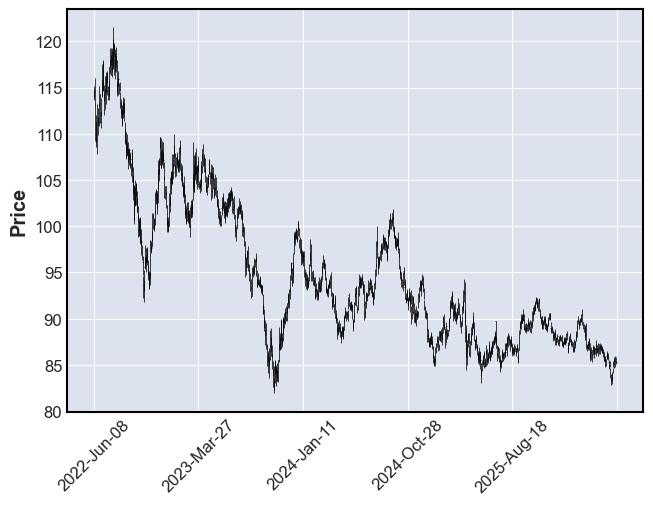

In [161]:
daily = split_adjusted_bars.resample('1D').agg({'open': 'first', 
                                 'high': 'max', 
                                 'low': 'min', 
                                 'close': 'last'})
daily.dropna(inplace=True)
mpf.plot(daily.tail(1000), type='ohlc', show_nontrading=False, warn_too_much_data=1000000)

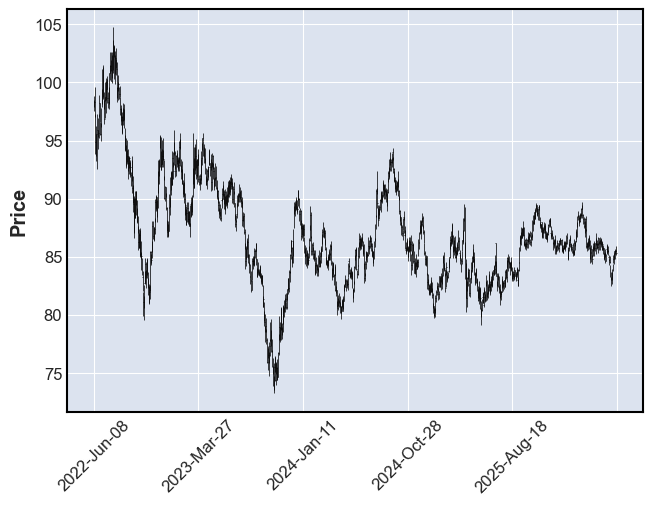

In [162]:
daily = all_adjusted_bars.resample('1D').agg({'open': 'first', 
                                 'high': 'max', 
                                 'low': 'min', 
                                 'close': 'last'})
daily.dropna(inplace=True)
mpf.plot(daily.tail(1000), type='ohlc', show_nontrading=False, warn_too_much_data=1000000)

# Dealing with edge cases

## Tickers with Negative Prices
We only had 1 such ticker "GEN-2016-06-06" that issued a Special Dividend that was $12 whilst it's close_original was $1.5
So the below helper function helps us deal with such scenarios in the Live environment hassle-free.

In [163]:
def write_blacklist_entry(ticker_id, ticker, blacklist_date, last_valid_date,
                          trigger_ratio, trigger_amount, prior_close,
                          reason="structural_break_dividend_negative_prices"):
    """
    Appends one row to the blacklist CSV.
    Idempotent: silently skips if ticker_id is already present.
    
    blacklist_date  = first UNTRADEABLE day (ex_date: the day prices go negative)
    last_valid_date = last day the stock was safely tradeable (cum_div_date)
    """
    entry = {
        'ticker_id':       ticker_id,
        'ticker':          ticker,
        'blacklist_date':  blacklist_date,
        'last_valid_date': last_valid_date,
        'reason':          reason,
        'trigger_ratio':   round(trigger_ratio, 4),
        'trigger_amount':  round(trigger_amount, 4),
        'prior_close':     round(prior_close, 4),
        'created_at':      datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    }

    if os.path.isfile(BLACKLIST_PATH):
        existing = pd.read_csv(BLACKLIST_PATH)
        if ticker_id in existing['ticker_id'].values:
            return  # already blacklisted; skip
        pd.DataFrame([entry]).to_csv(BLACKLIST_PATH, mode='a', header=False, index=False)
    else:
        pd.DataFrame([entry]).to_csv(BLACKLIST_PATH, mode='w', header=True, index=False)

# 7.5 Applying all adjustments via a Loop - to create adjusted-OHLCV parquet files (later on we merge the files for renamed tickers to get one continuous data series)

**(Dev: Tickers with Negative prices = Claude fixed his bug! Wow!)**

Later on, I got an error which was caused by stock prices being negative. This is caused by some special events (with a dividend type of 'SC'), where Polygon has already adjusted for it... We avoid this problem by manually deleting the dividend/split in the adjustment:
* GEN: 2020-02-03
* LIAN: 2024-02-26
* BBVA: 2014-12-17 (split)
* IRSA: the dividends are NOT split adjusted. Split adjust manually.
* KELYB: remove the 2015-05-14 dividend and add it to the dividend before. This ticker has almost no data. Same with 2018-05-21.
* KGC: remove the 2004-12-05 and 2004-12-06 split.
* SFE: remove the 2024-01-16 split. Apparently sometimes companies do a 100-to-1 and 1-to-100 at the same time to weed out shareholders that have less than 100 shares in some rare scenarios. When one of the two misses, we may get very incorrect prices.
* SPC: I have no idea what happened here. The stock price from 2005-2008 went from 40 to 0. No stock splits found. The ticker went delisted and then came back as SPB. However when looking at the TradingView charts, the price didn't seem to move much. I also couldn't find any dividends in the period 2005-2008 online. I will simply delete the dividend file.


In [164]:
tickers_v2 = get_tickers(v=2)
for index, row in tickers_v2.iterrows():
    id = row['ID']
    ticker = row["ticker"]
    start_date = row['start_date']
    end_date = row['end_date']

    # ==========================================
    # --- IDEMPOTENCY CHECK ---
    final_output_path = DATA_PATH + f"processed/m1/{id}.parquet"
    if os.path.isfile(final_output_path):
        continue
    # ==========================================

    try:
        dataset = pq.ParquetDataset(
            DATA_PATH + f"raw/m1/{ticker}.parquet",
            filters=[
                ("datetime", ">=", datetime.combine(start_date, time(4))),
                ("datetime", "<=", datetime.combine(end_date, time(20))),
            ],
        )
    except FileNotFoundError:
        continue

    bars = dataset.read().to_pandas()
    if bars.empty:
        continue

    # ADJUSTING
    split_adjusted_bars = split_adjust(bars, ticker)
    all_adjusted, break_meta = div_adjust(split_adjusted_bars, ticker)   # ── MODIFIED: unpack tuple ──

    # ── NEW: BLACKLIST HANDLING ───────────────────────────────────────────────────────────────────
    if break_meta['has_break']:
        write_blacklist_entry(
            ticker_id=id,
            ticker=ticker,
            blacklist_date=break_meta['blacklist_date'],
            last_valid_date=break_meta['last_valid_date'],
            trigger_ratio=break_meta['trigger_ratio'],
            trigger_amount=break_meta['trigger_amount'],
            prior_close=break_meta['prior_close'],
        )
        # If the structural break was at or before the very first bar, there is nothing
        # left to write. Skip the parquet entirely — the blacklist entry is sufficient.
        if all_adjusted.empty:
            print(f"⚠️  {id} ({ticker}): no bars remain after structural break truncation "
                  f"at {break_meta['last_valid_date']} — skipping parquet write")
            continue
    # ─────────────────────────────────────────────────────────────────────────────────────────────

    # FORWARD FILLING
    all_adjusted = reindex_and_fill(all_adjusted)

    # ROUNDING: TO 4 DECIMALS, TURNOVER TO INT
    all_adjusted = round(all_adjusted, 4)
    all_adjusted['turnover'] = all_adjusted['turnover'].astype(int)

    # ── MODIFIED: structural break detection should eliminate all negative prices. ────────────────
    # Any that remain here indicate an unknown adjustment issue — do NOT write a corrupt parquet.
    if (all_adjusted['close'] < 0).any():
        neg_count = (all_adjusted['close'] < 0).sum()
        print(f"🔴 {id} ({ticker}): {neg_count} negative prices still present after all "
              f"adjustments — skipping parquet write. INVESTIGATE.")
        continue
    # ─────────────────────────────────────────────────────────────────────────────────────────────

    all_adjusted.to_parquet(DATA_PATH + f"processed/m1/{id}.parquet", engine="fastparquet", row_group_offsets=25000)

(Took 4 hours) 

#### Issues:
```
⚠️ COMBINING MULTIPLE DIVIDENDS FOR TICKER: KELYB
Duplicated cum_div_dates: [datetime.date(2018, 2, 7)]
            amount cum_div_date
2018-02-23   0.075   2018-02-07
2018-05-21   0.075   2018-02-07
```

GEN-2016-06-06 has negative prices!


#### COMBINING MULTIPLE DIVIDENDS FOR TICKER: KELYB
- This is fine. We introduced this code as a bug fix for multiple dividends on the same date.

#### Tickers with Negative prices = ONLY one! Claude fixed his bug! Wow!
- GEN-2016-06-06 (delisted in 2021)
    - we have 2 GEN files. 
    - GEN-2016-06-06.parquet (now delisted company was using this ticker till 2021).
        - 2020-02-03 dividend was huge. Nearly 100x the usual dividend! But it was VALID! This was some "Special Dividend" of $12 (much higher than the close_original of $1.5) - https://www.sec.gov/Archives/edgar/data/849399/000110465920011259/tm206781d1_8k.htm 
        - So we can't remove this since it's a genuine dividend with it's SEC filing!
    - GEN-2022-11-08.parquet (unaffected. Separate company. We handle it correctly. Gen Digital Inc, formerly Symentac took over the ticker on this date)

##### Solution:
Dev overrides Claude: We can't just remove this stock with a look-ahead bias as Claude suggested. We want this system to also be trading Live and fetching data and scanning in the Live environment. So in the Live environment, it would have been trading GEN until this $12 dividend as we wouldn't know in advance whether we would get such a big dividend. So give me solutions that are realistic and resemble real market conditions. This stock should be part of the bias-free universe til this dividend's date and at this point it crosses all thresholds and hence becomes untradable and is marked as such and blacklisted from the universe. The same goes for similar stocks in the future. Claude agreed with our judgement call. 

The Right Mental Model: Live-First, Bias-Free
Your instinct is exactly right. The system should replay history as if you were trading live. GEN was a legitimate universe member until 2020-02-03. Retroactively removing its pre-break history introduces survivorship bias. The correct model is:
"The stock is valid until it crosses an automated threshold. At threshold crossing, it is immediately and permanently blacklisted. The historical record up to that date is preserved untouched."
CANDIDATE → ACTIVE → BLACKLISTED
                ↑
         (never re-admitted)

A ticker moves from ACTIVE to BLACKLISTED on the first session it breaches any structural break rule. It never re-enters. The GEN-2022-11-08 parquet (Gen Digital) is a separate CIK and gets its own independent lifecycle starting from its first traded date — your existing handling of this is already correct.

Code:
There are exactly three touch-points: a constants block, one new function (write_blacklist_entry), the modified div_adjust() (new break_meta init at top, structural break detection after cum_div_close, modified return), and the updated cell 48 loop. split_adjust() and get_dividends() are unchanged.


### List of tickers with Negative prices (should be empty now after all the safety checks we added)

In [165]:
# List of tickers with Negative prices

PROCESSED_PATH = "../data/polygon/processed/m1"
FILE_EXT = ".parquet"

for file in os.listdir(PROCESSED_PATH):
    if file.endswith(FILE_EXT):
        ticker = file.replace(FILE_EXT, "")
        file_path = os.path.join(PROCESSED_PATH, file)        
        
        df = pd.read_parquet(file_path)
        
        if (df['close'] < 0).any():
            print(f'{ticker} has negative prices!')

In [166]:
# Read some processed 1-min parquet files

df = pd.read_parquet(DATA_PATH + 'processed/m1/AAPL-2016-06-06.parquet')
df.head()

,open,high,low,close,close_original,turnover,volume,transactions,tradeable
datetime,,,,,,,,,
2016-06-06 04:00:00,22.2916,22.2916,22.2916,22.2916,98.17,0,0.0,0.0,False
2016-06-06 04:01:00,22.2916,22.2916,22.2916,22.2916,98.17,0,0.0,0.0,False
2016-06-06 04:02:00,22.2916,22.2916,22.2916,22.2916,98.17,0,0.0,0.0,False
2016-06-06 04:03:00,22.2916,22.2916,22.2916,22.2916,98.17,0,0.0,0.0,False
2016-06-06 04:04:00,22.2916,22.2916,22.2916,22.2916,98.17,0,0.0,0.0,False


In [167]:
df.tail()

,open,high,low,close,close_original,turnover,volume,transactions,tradeable
datetime,,,,,,,,,
2026-06-03 19:55:00,313.99,314.01,313.91,313.95,313.95,251160,800.0,65.0,True
2026-06-03 19:56:00,313.90,313.92,313.84,313.88,313.88,277156,883.0,27.0,True
2026-06-03 19:57:00,313.81,313.86,313.76,313.80,313.80,559191,1782.0,29.0,True
2026-06-03 19:58:00,313.86,313.90,313.86,313.90,313.90,324258,1033.0,38.0,True
2026-06-03 19:59:00,313.95,313.95,313.95,313.95,313.95,97952,312.0,22.0,True


In [ ]:
assert False

# 7.6 Updating the ticker list
Now that we have the data, we can add two columns <code>start_data</code> and <code>end_data</code>.

In [168]:
import pyarrow.parquet as pq

tickers_v2 = get_tickers(v=2)
# tickers_v2["start_data"] = np.nan
# tickers_v2["end_data"] = np.nan
tickers_v2["start_data"] = pd.NaT   # <- change to NaT
tickers_v2["end_data"] = pd.NaT     # <- change to NaT

for index, row in tickers_v2.iterrows():
    id = row['ID']
    try:
        dataset = pq.ParquetFile(DATA_PATH + f"processed/m1/{id}.parquet")
    except FileNotFoundError:
        #print(f"There is no data for {id}")
        continue

    # Reading metadata (statistics) of first and last row group. This avoids reading the entire file.
    # Reading everything from the datetime column and getting first/last row took 8 minutes. This took less than 50 sec.
    metadata_first_row_group = dataset.metadata.row_group(0)
    metadata_last_row_group = dataset.metadata.row_group(dataset.num_row_groups-1)
    # Retrieve statistics
    min_date = metadata_first_row_group.column(0).statistics.min
    max_date = metadata_last_row_group.column(0).statistics.max

    # print(f"min_date type: {type(min_date)}")
    # print(f"Column dtype before assignment: {tickers_v2['start_data'].dtype}")

    # Convert to date
    # start_data = min_date.to_pydatetime().date()
    # end_data = max_date.to_pydatetime().date()
    # start_data = min_date.date()
    # end_data = max_date.date()

    # O(n)
    # tickers_v2.loc[tickers_v2['ID'] == id, ["start_data", "end_data"] ] = [start_data, end_data]
    # O(1)
    # tickers_v2.at[index, 'start_data'] = start_data
    # tickers_v2.at[index, 'end_data'] = end_data
    # Explicit conversion to Timestamp
    tickers_v2.at[index, 'start_data'] = pd.Timestamp(min_date)
    tickers_v2.at[index, 'end_data'] = pd.Timestamp(max_date)


tickers_v2.reset_index(inplace=True)
tickers_v2[["ID", "ticker", "name", "active", "start_date", "end_date", "start_data", "end_data", "type", "cik", "composite_figi"]].to_csv("../data/tickers_v4.csv")

In [169]:
tickers_v4 = get_tickers(v=4)
tickers_v4['start_data'] = pd.to_datetime(tickers_v4['start_data']).dt.date
tickers_v4['end_data'] = pd.to_datetime(tickers_v4['end_data']).dt.date
tickers_v4.iloc[:3, :9].head(3)

,ID,ticker,name,active,start_date,end_date,start_data,end_data,type
0,A-2016-06-06,A,Agilent Technologies Inc.,True,2016-06-06,2026-06-03,2016-06-06,2026-06-03,CS
1,AA-2016-06-06,AA,Alcoa Corporation,True,2016-06-06,2026-06-03,2016-06-06,2026-06-03,CS
2,AAAP-2016-06-06,AAAP,Advanced Accelerator Applications S.A. America...,False,2016-06-06,2018-02-09,2016-06-06,2018-02-09,ADRC


Some stocks have zero data. There are the tickers with only ghost days. We can safely remove those.

In [170]:
zero_data = tickers_v4[tickers_v4['start_data'].isna()]
print(len(zero_data))
zero_data.iloc[:3, :9].head(3)

9579


,ID,ticker,name,active,start_date,end_date,start_data,end_data,type
102,ACCP-2016-12-14,ACCP,"Accelerated Pharma, Inc.",False,2016-12-14,2016-12-16,NaT,NaT,CS
103,ACCP-2017-05-11,ACCP,"Accelerated Pharma, Inc. Common Stock",False,2017-05-11,2017-05-12,NaT,NaT,CS
104,ACCP-2017-07-18,ACCP,"Accelerated Pharma, Inc. Common Stock",False,2017-07-18,2017-07-21,NaT,NaT,CS


In [171]:
tickers_v4 = tickers_v4[~(tickers_v4['start_data'].isna() & (tickers_v4['type'] != "INDEX"))]
tickers_v4.reset_index(inplace=True, drop=True)
tickers_v4.to_csv("../data/tickers_v4.csv")

In [172]:
tickers_v4 = get_tickers(v=4)
zero_data = tickers_v4[tickers_v4['start_data'].isna()]
print(len(zero_data))
zero_data.iloc[:3, :9].head(3)

0


,ID,ticker,name,active,start_date,end_date,start_data,end_data,type


In [173]:
assert False

AssertionError: 

# Join "adjusted" OHLCV data of both tickers

4. Continuity scaling (stitch)
- Multiplies the old ticker’s *entire* adjusted history by `close/close_original` from the new ticker. This is **not** a split/dividend – it’s a harmless scalar that aligns price levels. It cannot cause negative prices.

5. Join "adjusted" tickers data of both tickers
- Takes old data before the change date and new data from the change date onward. Creates a seamless, continuous price series with no artificial jumps.

There are a whopping 4347 ticker changes from 2003 to now that we have to take care of. But at least this was very easy to get.

Now we will use them to merge our data. We have to be aware that it is possible for a ticker to used multiple times, so the <code>ticker_changes.csv</code> may contain multiple of the same tickers in the 'from' and 'to' column. 

After processing the ticker changes we will create a <code>tickers_v5.csv</code> which will be our definitive ticker list. This contains a column 'tickers_old', which will contain a list of (date_of_change, ticker) pairs. So if A changes to B on day 2, and B changes to C on day 5, tickers_old for D will contain [[2, A], [5, B]].

The process will be as follows:
* As long as we have ticker changes to process
    * Loop through <code>tickers_v4.csv</code>.
        * Get the next trading date after 'end_date_data'.
        * Search in <code>tickers_changes.csv</code> if there is a ticker change on this date.
        * If it does:
            * The stock data will be merged.
            * In <code>tickers_v4.csv</code> we will change "ticker" to the new ticker and add a list [date, ticker] to "tickers_old".
            * All other rows will be merged such as "start_date". For identifiers such as FIGI we will take the last available value. For the ID we will keep the original. If we do not do this, we might run into problems with identical IDs.
            * The row of the old ticker will be deleted
            * **We need to restart the loop!** If we don't the following can happen: Let's assume that a ticker was renamed from A -> B -> C -> D but that the order in which it appears in our ticker list is C, D, A, B. Using our loop, C gets merged with D. Then the loop checks D, which has no renamings. Then A gets merged with B. Then B gets merged with C, however that is incorrect! B should be merged with the new D, which contains C. Any double+ renamings have the risk of being in the 'wrong order'.
                * For this to work, the ticker list must be sorted on end_date.
            * Of course we must not forget that there can be adjustments on day 1 of the ticker change. There should be laws to prohibit this.

#### A -> B -> C -> D (chained renamings)
The quote addresses a specific problem in data cleaning called **chained renamings**. 

Imagine a single company that changes its stock ticker multiple times over a few years:
1. **A** is renamed to **B**
2. **B** is renamed to **C**
3. **C** is renamed to **D**

In a perfect world, you would combine the historical data of **A** into **B**, then take that combined **A+B** data and merge it into **C**, and finally merge **A+B+C** into **D**. The active ticker **D** would then hold the entire history of the company. 

However, if your code just iterates straight through an unsorted list of tickers, it might encounter them in a random order, such as **C, D, A, B**. 
If the code processes them in this incorrect order without restarting:
1. It sees **C** and merges it into **D**. (Now **D** contains `C + D`, and **C** is deleted).
2. It sees **D** and does nothing (D wasn't renamed to anything else).
3. It sees **A** and merges it into **B**. (Now **B** contains `A + B`, and **A** is deleted).
4. It sees **B**, and knows **B** is supposed to merge into **C**. **But wait!** **C** was already deleted in step 1. The chain is broken. The code either crashes or leaves you with two fragmented histories: `A + B` and `C + D`.

**"The ticker list must be sorted on end_date"**: 
To fix this, the author notes that we must process the oldest events first. If you sort the tickers by the date they stopped trading under that name (`end_data`), **A** will always appear before **B**, **B** before **C**, and so on. 

##### How the Current Code Achieves This
The notebook uses a clever combination of a `while True` loop, a `for` loop, and `break` statements to ensure chronological processing. Here is the step-by-step breakdown of how the code accomplishes this:

**1. The Infinite Outer Loop & Sorting**
```python
while True:
    tickers_v4 = tickers_v4.sort_values(by='end_data').reset_index(drop=True)
```
Every time the loop starts (or restarts), the entire dataframe is explicitly sorted by `end_data`. Because of this, the ticker that "died" or was renamed the earliest will always be at the very top of the list.

**2. The Inner Search Loop**
```python
    for index_from, row_from in tickers_v4.copy().iterrows():
```
The code begins walking down the correctly sorted list, looking for the first ticker that has a known renaming event right after its `end_data`.

**3. The Merge and Deletion**
```python
        # Do the actual merging
        # ... parquet file manipulation ...
        
        tickers_v4.drop(index_from, inplace=True)
        tickers_v4.reset_index(inplace=True, drop=True)
```
Once it finds a match (e.g., merging **A** into **B**), it combines the data, updates the new ticker's historical start date, and completely deletes the old ticker (**A**) from the dataframe.

**4. Breaking to Restart (The Crucial Step)**
```python
        break
```
Immediately after successfully processing **a single merge**, the code hits a `break` statement. This `break` forcefully exits the inner `for` loop. Because it exits the `for` loop, the execution goes back to the top of the `while True` loop. 
The list is re-sorted, and the `for` loop **restarts from the very beginning**. This guarantees that the code never accidentally processes a later renaming before an earlier one, safely passing the "baton" from A -> B -> C -> D.

**5. The Termination Condition**
```python
    # If we have reached the end of the loop, it means we have processed everything. Then we can stop.
    if index_from >= (len(tickers_v4)-1):
        break
```
How does the infinite loop end? If the `for` loop checks every single ticker in the list and finds *no more renamings*, it naturally reaches the end of the list without ever hitting the first `break`. When `index_from` reaches the last row, the code knows the data is fully clean, triggers this final `break`, and exits the `while True` loop entirely.




Note: if a ticker A goes OTC and then comes back and changes to B, then we will have two files: one of the A before OTC and the A+B after OTC named B. This is as intended.

In [ ]:
tickers_v4 = get_tickers(v=4)
# QUICK BUG FIX, NEED TO REWRITE CODE TO MAKE IT CHRONOLOGICAL
market_dates = get_market_dates()
ticker_changes = get_ticker_changes()

END_DATE = market_dates[-1] # to not get "out of range" errors

# ── Augment ticker_changes with inferred status-suffix renamings ───────────────
# These (e.g. AAII → AAIIE) are not in stockanalysis.com but were inferred
# ── Augment ticker_changes with inferred status-suffix renamings ───────────────
try:
    inferred_path = PROCESSED + "inferred_renamings.csv"
    if os.path.exists(inferred_path):
        inferred = pd.read_csv(inferred_path, parse_dates=["date"])
        inferred["date"] = pd.to_datetime(inferred["date"]).dt.date

        tc_flat  = ticker_changes.reset_index()
        date_col = tc_flat.columns[0]

        inf_flat = (
            inferred[["date", "ticker_old", "ticker_new"]]
            .rename(columns={"date": date_col, "ticker_old": "from", "ticker_new": "to"})
        )

        n_before = len(ticker_changes)
        ticker_changes = (
            pd.concat([tc_flat, inf_flat], ignore_index=True)
            .drop_duplicates(subset=[date_col, "from"], keep="first")
            .set_index(date_col)
            .sort_index()
        )
        print(
            f"ticker_changes augmented: {n_before} → {len(ticker_changes)} entries "
            f"(+{len(inf_flat)} inferred suffix renames)"
        )
except Exception as e:
    print(f"[WARN] Inferred renamings augmentation skipped: {e}")
    print("[WARN] Main loop will proceed with unaugmented ticker_changes")


tickers_v4.insert(loc = 2, column = 'tickers_old', value = [{} for _ in range(len(tickers_v4))])

while True:
    tickers_v4 = tickers_v4.sort_values(by='end_data').reset_index(drop=True)

    # tickers_v4 gets smaller by 1 element every time we run this loop.
    for index_from, row_from in tickers_v4.copy().iterrows():
        # Get values
        type_from = row_from['type']
        if type_from == "INDEX":
            continue
        id_from = row_from['ID']
        ticker_from = row_from['ticker']
        start_date_from = row_from['start_date']
        end_date_from = row_from['end_date']
        start_data_from = row_from['start_data']
        end_data_from = row_from['end_data']

        # print(f"Working on {id_from}")

        # if end_data_from == END_DATE:
        if end_data_from == END_DATE:
            continue

        start_data_to = market_dates[market_dates.index(end_data_from) + 1]

        # Get ticker changes 
        change = ticker_changes[(ticker_changes.index == start_data_to) & (ticker_changes['from'] == ticker_from)]
        if change.empty:
            continue
        elif len(change) > 1:
            raise Exception("Duplicate!")
        ticker_to = change['to'].values[0]

        # Set values of new ticker
        row_to = tickers_v4[(tickers_v4['start_data'] == start_data_to) & (tickers_v4['ticker'] == ticker_to)]
        if row_to.empty:
            continue
        index_to = row_to.index[0]
        id_to = row_to['ID'].values[0]
        tickers_v4.loc[index_to, "tickers_old"][start_data_to.isoformat()] = ticker_from
        tickers_v4.loc[index_to, "start_date"] = start_date_from
        tickers_v4.loc[index_to, "start_data"] = start_data_from

        # --- IDEMPOTENCY CHECK 1 ---
        if not os.path.exists(DATA_PATH + f"processed/m1/{id_from}.parquet"):
            raise FileNotFoundError(f"[ERROR] {DATA_PATH + f"processed/m1/{id_from}.parquet"} is missing! Expected data for {ticker_from}.")

        from_ = pd.read_parquet(DATA_PATH + f"processed/m1/{id_from}.parquet")
        to = pd.read_parquet(DATA_PATH + f"processed/m1/{id_to}.parquet")

        # When a ticker changes, the adjustments carry over to the old ticker.
            # Get market close minute to calculate the adjustment factor, and adjust 'to'.
            # (Adjustment factor is the same throughout the day, so market close is arbitrarely chosen)
        # It is critically important to understand that this is NOT applying a split or dividend
        # It is simply re-denominating the old ticker's historical prices so they are quoted in the same "price scale" as the new ticker.
        # Example:
            # Price of Ticker OLD on 2024-01-01 (Change Date) is $10 (Actual Raw Price) and $10 (Adjusted Price).
            # Price of Ticker NEW on 2024-01-01 (Change Date) is $100 (Actual Raw Price) and $50 (Adjusted Price).
            # `adjustment_factor` = $50 / $100 = **0.5**
            # We multiply ALL of OLD's prices by 0.5: OLD on 2024-01-01 becomes $10 * 0.5 = **$5** 
            # Now, the day _before_ the change, OLD sits at **$5** (adjusted scale). 
            # The day *after* the change, NEW sits at **$5** (adjusted scale).    
            # **Result:** A perfectly flat, continuous price history with no artificial jumps. 
            # And for tickers that don't need a change, adjustment_factor is 1.
        calendar = get_market_calendar('datetime')
        start_data_to_dt = calendar.loc[start_data_to, 'regular_close']
        start_data_to_dt_bar = to.loc[start_data_to_dt]
        adjustment_factor = start_data_to_dt_bar['close'] / start_data_to_dt_bar['close_original']
        from_[['open', 'high', 'low', 'close']] = from_[['open', 'high', 'low', 'close']].multiply(adjustment_factor)
        from_ = round(from_, 4)

        # # If on the old ticker, there are divs/splits on start_data_to (start of new ticker), then something is wrong.
        # if os.path.isfile(DATA_PATH + f"raw/adjustments/{ticker_from}.csv"):
        #     adjustments = pd.read_csv(DATA_PATH + f"raw/adjustments/{ticker_from}.csv", parse_dates=True, index_col=0)
        #     adjustments.index = pd.to_datetime(adjustments.index).date
        #     adjustments = adjustments[(adjustments.index == start_data_to)]
        #     assert len(adjustments) == 0

        # Remove the 'from' ticker, then paste the 'from' and 'to' ticker to m1_renamed for debugging purposes.
        _ = shutil.move(DATA_PATH + f'processed/m1/{id_from}.parquet', DATA_PATH + f'processed/m1_renamed/{id_from}.parquet')
        _ = shutil.copyfile(DATA_PATH + f'processed/m1/{id_to}.parquet', DATA_PATH + f'processed/m1_renamed/{id_to}.parquet')

        pd.concat([from_, to]).to_parquet(DATA_PATH + f"processed/m1/{id_to}.parquet", engine="fastparquet", row_group_offsets=25000)

        tickers_v4.drop(index_from, inplace=True)
        tickers_v4.reset_index(inplace=True, drop=True)
        
        print(f"Ticker change {ticker_from} -> {ticker_to} on {start_data_to} has been processed")
        print(f"{index_from/len(tickers_v4)*100:.1f}% | Length of tickers_v4 is {len(tickers_v4)}")
        break

    # If we have reached the end of the loop, it means we have processed everything. Then we can stop.
    if index_from >= (len(tickers_v4)-1):
        break
    
tickers_v4 = tickers_v4.sort_values(by='ID').reset_index(drop=True)

tickers_v4.to_csv("../data/tickers_v5.csv")

In [ ]:
print(f"Last date in market_dates: {market_dates[-1]}")
print(f"end_data_from: {end_data_from}")
print(f"END_DATE: {END_DATE}")
print(f"Index of end_data_from: {market_dates.index(end_data_from)}")


In [ ]:
tickers_v5 = get_tickers(v=5)
renamings = tickers_v5[tickers_v5["tickers_old"].str.len() > 2] # These were renamed
print(len(renamings))
tickers_v5[tickers_v5['ticker'] == 'META']

In [ ]:
# Check for Negative Prices again! Think I saw one!

# List of tickers with Negative prices
PROCESSED_PATH = "../data/polygon/processed/m1"
FILE_EXT = ".parquet"

for file in os.listdir(PROCESSED_PATH):
    if file.endswith(FILE_EXT):
        ticker = file.replace(FILE_EXT, "")
        file_path = os.path.join(PROCESSED_PATH, file)        
        
        df = pd.read_parquet(file_path)
        
        if (df['close'] < 0).any():
            print(f'{ticker} has negative prices!')

# Verify that all the Data Cleaning processes have been applied correctly! Especially for stocks with ticker changes. 
# **in the end, we verify everything manually using tickers like FB/META that had ticker_changes AND Splits AND dividends and making sure that the Price matches that of tradingview in 2016-06-15!**


## Verify OHLC and Volume. Read parquet files to verify backfills, transactions, turnover, volume, etc.
Example Ticker Changes: FB/META, BITF/KEEL, XON/XOM, WTW/WW, MMC/MRSH, LB/VSCO, RTN/RTX, GEN (formerly symantec)


## Verify many tickers by Plotting their charts and comparing against Tradingview 

Example Ticker Changes: FB/META, BITF/KEEL, XON/XOM, WTW/WW, MMC/MRSH, LB/VSCO, RTN/RTX, GEN (formerly symantec)

Furthermore, several large-cap companies have completely changed the exchange they trade on rather than their ticker—such as T-Mobile, Honeywell, and Kraft Heinz—which transferred their primary listings from the NYSE to the Nasdaq.
TMUS, HON, KHC

T-Mobile: Changed from TMUS to T (or various tracker shifts) following their merger with Sprint.
TMUS/T


In [ ]:
# Plots of Daily data

# tickers = ['META', 'KEEL', 'XOM', 'WW', 'MRSH', 'VSCO', 'RTX', 'GEN', 'HON', 'KHC', 'TMUS', 'T']
tickers = ['META', 'KEEL']


for ticker in tickers:
    all_adjusted_bars = pd.read_parquet(f"{DATA_PATH}processed/m1/{ticker}.parquet")

    # Resample to daily OHLC
    daily = all_adjusted_bars.resample('1D').agg({'open': 'first', 
                                    'high': 'max', 
                                    'low': 'min', 
                                    'close': 'last'})

    # Remove any rows where all OHLC columns are NaN (if any)
    daily.dropna(inplace=True)

    # Plot last 10,000 days
    mpf.plot(daily.tail(10000), type='candle', show_nontrading=False, warn_too_much_data=1000000)

In [ ]:
# Plots of 1-min data

# List of tickers (or just one)
tickers = ['META', 'KEEL', 'XOM', 'WW', 'MRSH', 'VSCO', 'RTX', 'GEN', 'HON', 'KHC', 'TMUS', 'T']

for ticker in tickers:
    # Read the 1-minute parquet file
    df = pd.read_parquet(f"{DATA_PATH}processed/m1/{ticker}.parquet")

    # Ensure the index is datetime (it usually is)
    # If not, set it: df.index = pd.to_datetime(df.index)

    # Drop any rows where all OHLC are NaN
    df.dropna(subset=['open', 'high', 'low', 'close'], how='all', inplace=True)

    # --- Plot the last N bars (e.g., 10000 minutes ≈ 12-13 trading days) ---
    # Adjust the number based on your screen/memory
    mpf.plot(df.tail(10000), 
             type='candle',          # or 'candle' for candlesticks
             volume=True,         # set to True if you have volume column
             show_nontrading=False,
             warn_too_much_data=1000000,
             title=f"{ticker} - 1-min OHLC",
             figsize=(12, 6))

Tickers that were renamed multiple times:

In [ ]:
multiple_renamings = tickers_v5[tickers_v5["tickers_old"].str.len() > 23]
print(len(multiple_renamings))
multiple_renamings.head(2)

# Data Cleaning is Finished!
Now we have multiple ticker lists. These are:
1. Basic ticker list with a lot of incorrect duplications.
2. Duplications merged and incorrect tickers removed.
3. Data start/end dates added (in 03_tickers.ipynb). 
4. ETFs added.
5. Adjustments (Splits, Dividends) applied whilst keeping `close_original` for PIT Price.
6. Data Cleaned thoroughly (with "backfills" applied to all 1-min bars - especially useful for Pre-mkt bars) under 07_process.ipynb
7. Renamings (ticker changes) merged and stitched (FB/META, BITF/KEEL). tickers_definitive_with_renamings.csv

**Only the last should be used in backtesting.**

If Polygon just provided these from the start, it would have saved countless hours. But at least I learned some Python I guess. And at least Polygon does not ask thousands.

# BELOW IS FROM the earlier "07_process" FILE! Updates section from this old file and the old 08_renamings file will need to be used and added to, to make the updates work as expect. LATER

# 7.7 Updates
- Load the functions
- Update trading_minutes
- Put everything in m1_renamed to m1, to reverse renamings.
- Run below cells.
- Run 7.6

Loop through v3:
- If the ID is in the (old) <code>tickers_v4</code> and <code>end_date</code>(v3) is larger than the old_END_DATE (v4), then we know this is a ticker that kept its listing. Do the processing on the new part only. However we must not forget that adjustments carry over to the old data. If in the new data there is a 100:1 split, all old data has to be multiplied with 100x. (Adjustments are really annoying. Dividends and splits should just be banned. Brokers should just quote in 10e-6 for stocks that dilute to infinity. Dividends can be perfectly replaced with share buybacks.)
- If the ID is not in <code>tickers_v4</code> AND start_date (v3) is larger than old_END_DATE, it's a new listing. Do the processing on the entire file.

In [ ]:
from times import first_trading_date_after
from fastparquet import write
import pyarrow.parquet as pq

In [ ]:
old_tickers_v4 = pd.read_csv("../data/tickers_v4_OLD.csv", index_col=0)
old_tickers_v4 = old_tickers_v4[old_tickers_v4['type'].isin(['CS', 'ADRC', 'ETN', 'ETV', 'ETF'])]
old_END_DATE = date.fromisoformat(old_tickers_v4['end_date'].max())
old_IDs = list(old_tickers_v4['ID'])

process_from_dt = datetime.combine(first_trading_date_after(old_END_DATE), time(4))

In [ ]:
tickers_v2 = get_tickers(v=2, types=["CS", "ADRC", "ETF", "ETN", "ETV"])

for index, row in tickers_v2.iterrows():
    id = row["ID"]
    ticker = row["ticker"]
    start_date = row["start_date"]
    end_date = row["end_date"]

    if id in old_IDs and end_date > old_END_DATE:
        try:
            dataset = pq.ParquetDataset(
            DATA_PATH + f"raw/m1/{id}.parquet", filters=[("datetime", ">=", process_from_dt)])
        except FileNotFoundError:
            print(f"There is no data for {id}")
            continue

        bars = dataset.read().to_pandas()

        if bars.empty:
            continue

        # ADJUSTING
        split_adjusted_bars = split_adjust(bars, ticker)
        all_adjusted = div_adjust(split_adjusted_bars, ticker)

        # FORWARD FILLING
        all_adjusted = reindex_and_fill(all_adjusted)

        # ROUNDING: TO 4 DECIMALS, TURNOVER TO INT
        all_adjusted = round(all_adjusted, 4)
        all_adjusted['turnover'] = all_adjusted['turnover'].astype(int)

        if (all_adjusted['close'] < 0).any():
            raise Exception(f'{id} has negative prices!')

        # Of course, an adjustment can take place on exactly the boundary.
        has_adjustments = False
        if os.path.isfile(DATA_PATH + f"raw/adjustments/{ticker}.csv"):
            adjustments = pd.read_csv(DATA_PATH + f"raw/adjustments/{ticker}.csv", parse_dates=True, index_col=0)
            adjustments.index = pd.to_datetime(adjustments.index).date
            adjustments = adjustments[(adjustments.index == first_trading_date_after(old_END_DATE))]
            has_adjustments = True

        # Adjustment need to carry over, however we first process the adjustments on the boundary.
        new_bars_first_bar = all_adjusted.iloc[0]
        adjustment_factor = new_bars_first_bar['close'] / new_bars_first_bar['close_original']
        if has_adjustments or adjustment_factor != 1:
            old_bars = pd.read_parquet(DATA_PATH + f"processed/m1/{id}.parquet")

        if has_adjustments:
            # SPLIT ADJUSTMENT
            split = adjustments[adjustments.type == 'SPLIT']
            if len(split) > 0:
                split_amount = split['amount'][0]
                old_bars[['open', 'high', 'low', 'close']] = old_bars[['open', 'high', 'low', 'close']].multiply(split_amount)

            # DIVIDEND ADJUSTMENT - REUN is the only case, not clear what happened there, likely a 'special dividend'
            dividend = adjustments[adjustments.type == 'DIV']
            if len(dividend) > 0:
                market_hours = get_market_calendar()
                market_hours = market_hours[['regular_close']]

                cum_div_date = old_END_DATE
                cum_div_time = market_hours.loc[cum_div_date][0]
                cum_div_datetime = datetime.combine(cum_div_date, cum_div_time)
                cum_div_datetime = (old_bars[old_bars.index <= cum_div_datetime].index).max()
                cum_div_close = old_bars.loc[cum_div_datetime, 'close']
                dividend_amount = dividend['amount'][0]
                    
                adjustment_factor = 1 - dividend_amount/cum_div_close

                old_bars[['open', 'high', 'low', 'close']] = old_bars[['open', 'high', 'low', 'close']].multiply(adjustment_factor)

            # ROUNDING
            if len(split) > 0 or len(dividend) > 0:
                old_bars = round(old_bars, 4)
                old_bars['turnover'] = old_bars['turnover'].astype(int)

        # New adjustments carry over to old data...
        new_bars_first_bar = all_adjusted.iloc[0]
        adjustment_factor = new_bars_first_bar['close'] / new_bars_first_bar['close_original']

        if adjustment_factor != 1:
            old_bars[['open', 'high', 'low', 'close']] = old_bars[['open', 'high', 'low', 'close']].multiply(adjustment_factor)
            old_bars = round(old_bars, 4)
        
        if has_adjustments or adjustment_factor != 1:
            all_bars = pd.concat([old_bars, all_adjusted])
            # Because not all stocks trade on all days, there may be a gap between the old and new bars. We have to refill them.
            reindex_and_fill(all_bars).to_parquet(DATA_PATH + f"processed/m1/{id}.parquet", engine="fastparquet", row_group_offsets=25000)
        else:
            write(DATA_PATH + f"processed/m1/{id}.parquet", all_adjusted, append=True)

    elif id not in old_IDs and start_date > old_END_DATE:
        try:
            bars = pd.read_parquet(f"{DATA_PATH}raw/m1/{id}.parquet")
        except FileNotFoundError:
            print(f"There is no data for {id}")
            continue

        # ADJUSTING
        split_adjusted_bars = split_adjust(bars, ticker)
        all_adjusted = div_adjust(split_adjusted_bars, ticker)

        # FORWARD FILLING
        all_adjusted = reindex_and_fill(all_adjusted)

        # ROUNDING: TO 4 DECIMALS, TURNOVER TO INT
        all_adjusted = round(all_adjusted, 4)
        all_adjusted['turnover'] = all_adjusted['turnover'].astype(int)

        if (all_adjusted['close'] < 0).any():
            raise Exception(f'{id} has negative prices!')
        
        all_adjusted.to_parquet(DATA_PATH + f"processed/m1/{id}.parquet", engine="fastparquet", row_group_offsets=25000)


In [ ]:
# all_files = os.listdir(DATA_PATH + f'raw/adjustments/')
# for index, file in enumerate(all_files):
#     adjustments = pd.read_csv(DATA_PATH + f'raw/adjustments/{file}')
#     if not adjustments[adjustments['type'] == 'DIV'].empty:
#         dividends = adjustments[adjustments['type'] == 'DIV']
#         indices_to_remove = dividends[dividends[['date', 'type']].duplicated(keep='last')].index
#         adjustments = adjustments.drop(index=indices_to_remove)
#     if not adjustments[adjustments['type'] == 'SPLIT'].empty:
#         splits = adjustments[adjustments['type'] == 'SPLIT']
#         indices_to_remove = splits[splits[['date', 'type']].duplicated(keep='last')].index
#         adjustments = adjustments.drop(index=indices_to_remove)
#     adjustments.to_csv(DATA_PATH + f'raw/adjustments/{file}', index=False)

# 8.2 Updates
Rerun the file after setting END_DATE and updating the list of renamings.